In [38]:
!pip install lime optuna shap catboost hmmlearn -q

In [39]:
!python -m pip install -U git+https://github.com/cair/tmu.git -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [40]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [53]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import RobustScaler, KBinsDiscretizer, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import BayesianRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn import linear_model
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import optuna
import warnings
import time
from hmmlearn.hmm import GaussianHMM

from tmu.models.regression.vanilla_regressor import TMRegressor
from optuna.samplers import TPESampler
from optuna.pruners import HyperbandPruner
from sklearn.base import clone

import lime
import lime.lime_tabular
import math
from sklearn.linear_model import LinearRegression

# data loading and preprocessing

In [66]:
df = pd.read_csv("/content/drive/MyDrive/Forecasting-Agent-for-Fintech/data/macro/japan_volatility_merged_daily_1990_2024.csv", parse_dates=["Date"])
df = df.drop(columns=["DEXJPUS", "DEXJPUS_LOG", "DEXJPUS_PCT_CHANGE"])

# ── Variable definitions ──────────────────────────────────────────────────────
macro_vars = [
    "b30ret","b20ret","b10ret","b7ret","b5ret","b2ret","b1ret",
    "t90ret","t30ret","cpiret","wti_price","fedfunds","nfci","anfci",
    "nfci_risk","nfci_credit","nfci_leverage","nfci_nonfinancial_leverage",
    "gdp","gdp_growth","ppi","unrate","usd_index","trade_balance",
    "PERMNO", "BIDLO", "ASKHI", "PRC", "VOL", "RET",
    "SHROUT", "CFACPR", "RETX", "sprtrn",
    "Close", "High", "Low", "Open", "Volume"
]

micro_vars = [
    "XTIMVA01JPM667S","JPNPROINDMISMEI","JPNCPIALLMINMEI",
    "IRSTCI01JPM156N","IRLTLT01JPM156N",
    "N225_Open","N225_High","N225_Low","N225_Close",
    "N225_Adj_Close","N225_Volume"
]

TARGET_COL  = "DEXJPUS_LOG_RETURN"
TEST_DAYS   = 262

In [67]:
df["Date"] = pd.to_datetime(df["Date"])
before = len(df)
#removed weekends
df = df[df["Date"].dt.dayofweek < 5].reset_index(drop=True)
print(f"Removed {before - len(df)} weekend rows | Remaining: {len(df)}")

before = len(df)
df = df.dropna(subset=[TARGET_COL]).reset_index(drop=True)
print(f"\nDropped {before - len(df)} rows where target DEXJPUS is NaN")

#df.isnull().sum()
df[macro_vars] = df[macro_vars].ffill()

# check number of days in each year
# df["Date"] = pd.to_datetime(df["Date"])
# print(df.groupby(df["Date"].dt.year).size())


Removed 3652 weekend rows | Remaining: 9132

Dropped 348 rows where target DEXJPUS is NaN


# source code

In [68]:
def standard_importance(fitted_model, pipeline, X_train, y_train, feature_names):
    if hasattr(fitted_model, 'feature_importances_'):
        importances = fitted_model.feature_importances_
    elif hasattr(fitted_model, 'coef_'):
        importances = np.abs(fitted_model.coef_)
    else:
        perm        = permutation_importance(pipeline, X_train, y_train,
                                             n_repeats=10, random_state=42)
        importances = perm.importances_mean
    return pd.DataFrame({
        'feature':    feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).reset_index(drop=True)

def shap_importance(fitted_model, X_train, feature_names):
    X_train_df  = pd.DataFrame(X_train, columns=feature_names)
    tree_models = (RandomForestRegressor, GradientBoostingRegressor,
                   XGBRegressor, CatBoostRegressor)
    if isinstance(fitted_model, tree_models):
        explainer   = shap.TreeExplainer(fitted_model)
        shap_values = explainer.shap_values(X_train_df)
    else:
        explainer   = shap.KernelExplainer(
            fitted_model.predict, shap.sample(X_train_df, 50))
        shap_values = explainer.shap_values(X_train_df)
    importances = np.abs(shap_values).mean(axis=0)
    return pd.DataFrame({
        'feature':    feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).reset_index(drop=True), shap_values, X_train_df

def permutation_importance_ranked(pipeline, X_train, y_train, feature_names):
    perm = permutation_importance(pipeline, X_train, y_train,
                                  n_repeats=20, random_state=42)
    return pd.DataFrame({
        'feature':    feature_names,
        'importance': perm.importances_mean,
        'std':        perm.importances_std
    }).sort_values('importance', ascending=False).reset_index(drop=True)

def lime_importance(fitted_model, X_train, X_test, feature_names, model_name):
    explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data        = X_train,
        feature_names        = feature_names,
        mode                 = 'regression',
        discretize_continuous= True,
        random_state         = 42
    )

    n_samples   = min(50, len(X_test))
    sample_idx  = np.linspace(0, len(X_test) - 1, n_samples, dtype=int)
    X_test_sample = X_test[sample_idx]

    all_weights = []
    for i in range(len(X_test_sample)):
        exp          = explainer.explain_instance(
            X_test_sample[i],
            fitted_model.predict,
            num_features = len(feature_names),
            num_samples  = 300
        )
        weights_dict = dict(exp.as_list())
        row          = {f: 0.0 for f in feature_names}
        for key, val in weights_dict.items():
            for fname in feature_names:
                if fname in key:
                    row[fname] = val
                    break
        all_weights.append(row)

    lime_df = pd.DataFrame(all_weights)

    fi_lime = pd.DataFrame({
        'feature':     feature_names,
        'importance':  lime_df.abs().mean().values,
        'mean_effect': lime_df.mean().values,
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(fi_lime.head(20)) * 0.35)))

    top = fi_lime.head(20)
    axes[0].barh(top['feature'][::-1], top['importance'][::-1], color='mediumpurple')
    axes[0].set_title(f"LIME — Mean |Weight| ({model_name})")
    axes[0].set_xlabel("Mean Absolute LIME Weight")
    axes[0].grid(True, alpha=0.3)

    colors = ['tomato' if v < 0 else 'steelblue' for v in top['mean_effect'][::-1]]
    axes[1].barh(top['feature'][::-1], top['mean_effect'][::-1], color=colors)
    axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
    axes[1].set_title(f"LIME — Direction of Effect ({model_name})\nBlue=increases volatility, Red=decreases volatility")
    axes[1].set_xlabel("Mean Signed LIME Weight")
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f"LIME Feature Importance — {model_name}", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return fi_lime

In [69]:
def plot_macro_bar(fi_df, title):
    fig, ax = plt.subplots(figsize=(7, max(4, len(fi_df) * 0.35)))
    ax.barh(fi_df['feature'][::-1], fi_df['importance'][::-1], color='steelblue')
    ax.set_title(title)
    ax.set_xlabel("Importance")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_permutation(fi_df, model_name):
    fig, ax = plt.subplots(figsize=(7, max(4, len(fi_df) * 0.35)))
    top = fi_df.head(20)
    ax.barh(top['feature'][::-1], top['importance'][::-1],
            xerr=top['std'][::-1] if 'std' in top.columns else None,
            color='mediumseagreen', capsize=3)
    ax.set_title(f"Permutation Importance — Top 20\n({model_name})")
    ax.set_xlabel("Mean accuracy decrease (±std)")
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_shap(shap_values, X_train_df, model_name):
    plt.figure()
    shap.summary_plot(shap_values, X_train_df, plot_type="bar", show=False)
    plt.title(f"SHAP — Mean |SHAP| ({model_name})")
    plt.tight_layout()
    plt.show()

    plt.figure()
    shap.summary_plot(shap_values, X_train_df, show=False)
    plt.title(f"SHAP — Direction & Magnitude ({model_name})")
    plt.tight_layout()
    plt.show()

# modelling

In [70]:

def compute_and_plot_importance(strategy, fitted_model, pipeline,
                                X_train, y_train, feature_names,
                                macro_vars, model_name, use_macro,
                                X_test=None):
    run_standard    = strategy in ('standard',    'all')
    run_shap        = strategy in ('shap',        'all')
    run_permutation = strategy in ('permutation', 'all')
    run_lime        = strategy in ('lime',        'all')

    fi_standard = fi_shap = fi_perm = fi_lime = None

    if run_standard:
        fi_standard = standard_importance(fitted_model, pipeline,
                                          X_train, y_train, feature_names)
        macro_fi    = fi_standard[fi_standard['feature'].apply(
                          lambda f: any(f == m or f.startswith(m + "_")
                                        for m in macro_vars))].reset_index(drop=True)
        other_fi    = fi_standard[~fi_standard.index.isin(macro_fi.index)].reset_index(drop=True)
        if use_macro and not macro_fi.empty:
            plot_macro_bar(macro_fi, f"Standard Importance — Macro\n({model_name})")
        if not other_fi.empty:
            plot_macro_bar(other_fi, f"Standard Importance — Japan/FX Features\n({model_name})")

    if run_shap:
        fi_shap, shap_values, X_train_df = shap_importance(fitted_model, X_train, feature_names)
        plot_shap(shap_values, X_train_df, model_name)

    if run_permutation:
        fi_perm = permutation_importance_ranked(pipeline, X_train, y_train, feature_names)
        plot_permutation(fi_perm, model_name)

    if run_lime:
        if X_test is not None:
          n_samples  = min(50, len(X_test))
          sample_idx = np.linspace(0, len(X_test) - 1, n_samples, dtype=int)
          fi_lime    = lime_importance(fitted_model, X_train,
                                     X_test[sample_idx],
                                     feature_names, model_name)
        else:
          print("LIME skipped — X_test not passed to compute_and_plot_importance")
    return fi_standard, fi_shap, fi_perm, fi_lime


In [71]:
def run_arima_fx(y_train, y_test, test_dates,
                 X_train=None, X_test=None, use_macro=False):
    """
    ARIMA/ARIMAX for USD/JPY % change forecasting.
    Only lag1 macro columns used as exog to avoid multicollinearity.
    """
    exog_train = exog_test = None

    if use_macro and X_train is not None:
        macro_lag_cols = [c for c in X_train.columns
                          if c.endswith('_lag1')
                          and not any(c.startswith(v) for v in
                                      [TARGET_COL] + micro_vars)]
        if macro_lag_cols:
            exog_train = X_train[macro_lag_cols].values
            exog_test  = X_test[macro_lag_cols].values
            print(f"  ARIMAX exog cols ({len(macro_lag_cols)}): {macro_lag_cols[:5]}...")

    best_result = None
    best_aic    = np.inf

    for p in [1, 2, 5]:
        for d in [0, 1]:
            for q in [0, 1]:
                try:
                    m = SARIMAX(y_train, exog=exog_train,
                                order=(p, d, q),
                                seasonal_order=(1, 0, 0, 5),
                                enforce_stationarity=False,
                                enforce_invertibility=False).fit(disp=False)
                    if m.aic < best_aic:
                        best_aic    = m.aic
                        best_result = m
                except Exception:
                    continue

    if best_result is None:
        raise RuntimeError("ARIMA: no model converged.")

    start       = time.time()
    predictions = np.array(best_result.forecast(steps=len(y_test),
                                                  exog=exog_test))
    end         = time.time()

    rmse = math.sqrt(mean_squared_error(y_test, predictions))
    mae  = mean_absolute_error(y_test, predictions)
    mape = mean_absolute_percentage_error(y_test, predictions) * 100
    r2   = r2_score(y_test, predictions)

    results = pd.DataFrame({
        "date":           test_dates.values,
        "actual_fx":      y_test.values,
        "predicted_fx":   predictions
    })

    print(f"\n{'='*65}")
    print(f"{'ARIMA' if not use_macro else 'ARIMAX'} — Best AIC: {best_aic:.2f}")
    print(f"{'Date':<15} {'Actual':>12} {'Predicted':>12} {'Error':>10}")
    print(f"{'-'*65}")
    for _, row in results.iloc[::21].iterrows():
        error = abs(row['actual_fx'] - row['predicted_fx'])
        print(f"{str(row['date'])[:10]:<15} {row['actual_fx']:>12.5f} "
              f"{row['predicted_fx']:>12.5f} {error:>10.5f}")
    print(f"  (showing every ~21 days)")
    print(f"{'-'*65}")
    print(f"{'RMSE:':>45} {rmse:.6f}")
    print(f"{'MAE:':>45}  {mae:.6f}")
    print(f"{'MAPE (%):':>45} {mape:.2f}")
    print(f"{'R²:':>45} {r2:.4f}")
    print(f"Inference time: {(end - start) * 1000:.3f} ms")
    print(f"{'='*65}")

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(results["date"], results["actual_fx"],    linewidth=1.5, label="Actual")
    ax.plot(results["date"], results["predicted_fx"], linewidth=1.5,
            label="Predicted", alpha=0.8)
    ax.xaxis.set_major_locator(plt.MaxNLocator(10))
    plt.xticks(rotation=45)
    ax.set_xlabel("Date")
    ax.set_ylabel("USD/JPY % Change")
    ax.set_title(f"USD/JPY — {'ARIMAX' if use_macro else 'ARIMA'}\n"
                 f"(R²={r2:.3f}  RMSE={rmse:.6f}  MAE={mae:.6f})")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return results, rmse, mae, mape, r2


In [72]:
def _shap_guided_binarise(X_train, X_test, model, min_bins=5, max_bins=20):
    """
    Binarise each feature with n_bins proportional to its SHAP importance.
    High-importance features → max_bins (20), low-importance → min_bins (5).
    """
    # explainer   = shap.Explainer(model, X_train) #,silent=True
    explainer = shap.TreeExplainer(model, feature_perturbation="tree_path_dependent")
    # shap_values = explainer(X_train).values
    shap_values = explainer.shap_values(X_train)
    mean_abs    = np.abs(shap_values).mean(axis=0)

    imp_min, imp_max = mean_abs.min(), mean_abs.max()
    if imp_max - imp_min < 1e-9:
        norm = np.ones_like(mean_abs)
    else:
        norm = (mean_abs - imp_min) / (imp_max - imp_min)

    n_bins_per_feat = np.round(
        min_bins + norm * (max_bins - min_bins)
    ).astype(int)

    print(f"\n  SHAP-guided bins — min:{n_bins_per_feat.min()} "
          f"max:{n_bins_per_feat.max()} "
          f"mean:{n_bins_per_feat.mean():.1f}")

    # Binarise each feature independently
    tr_cols, te_cols = [], []
    for j, nb in enumerate(n_bins_per_feat):
        binner = KBinsDiscretizer(n_bins=nb, encode='ordinal', strategy='quantile')
        tr_cols.append(binner.fit_transform(X_train[:, [j]]))
        te_cols.append(binner.transform(X_test[:, [j]]))

    X_tr_bits = np.hstack(tr_cols).astype(np.uint32)
    X_te_bits = np.hstack(te_cols).astype(np.uint32)
    return X_tr_bits, X_te_bits, n_bins_per_feat

def fit_regime_hmm(df, n_regimes=2, regime_features=None):
    if regime_features is None:
        regime_features = [c for c in ["nfci", "fedfunds", "unrate", "cpiret_lag1"]
                           if c in df.columns]

    if len(regime_features) == 0:
        raise ValueError("No regime features found in DataFrame.")

    X_reg = df[regime_features].ffill().bfill().values
    regime_scaler = StandardScaler()
    X_reg_sc      = regime_scaler.fit_transform(X_reg)

    hmm = GaussianHMM(
        n_components  = n_regimes,
        covariance_type = "full",
        n_iter        = 200,
        random_state  = 42
    )
    hmm.fit(X_reg_sc)
    regimes = hmm.predict(X_reg_sc)

    # Identify which label = recession: higher mean unrate / nfci = stress
    if "unrate" in regime_features:
        stress_idx = np.argmax([
            X_reg_sc[regimes == r, regime_features.index("unrate")].mean()
            for r in range(n_regimes)
        ])
    else:
        stress_idx = np.argmax([
            X_reg_sc[regimes == r].mean()
            for r in range(n_regimes)
        ])

    # Remap so regime 1 = stress/recession, 0 = expansion
    if stress_idx == 0:
        regimes = 1 - regimes

    counts = {0: (regimes == 0).sum(), 1: (regimes == 1).sum()}
    print(f"  HMM regimes — Expansion: {counts[0]}q | Stress/Recession: {counts[1]}q")
    print(f"  Features used: {regime_features}")

    return hmm, regimes, regime_scaler, regime_features

def detect_regime(hmm, regime_scaler, regime_features, X_row_df, stress_idx_is_1=True):
    """
    Predict regime for a single row (as DataFrame).
    Returns 0 (expansion) or 1 (recession/stress).
    """
    avail = [c for c in regime_features if c in X_row_df.columns]
    X_reg = X_row_df[avail].values.reshape(1, -1)
    X_sc  = regime_scaler.transform(X_reg)
    label = hmm.predict(X_sc)[0]
    return int(label)


In [73]:
def run_tsetlin_fx(X_train, X_test, y_train, y_test, test_dates,
                   feature_names, importance_strategy, feature_selection,
                   hybrid=True, n_bins=10, epochs=30,
                   tune=True, n_trials=50, use_macro=True,
                   shap_binarise=False, min_bins=5, max_bins=30,
                   use_regime=False, n_regimes=2,
                   regime_features=["nfci", "fedfunds",
                                    "IRLTLT01JPM156N", "fx_lag1"]):

    if not use_macro:
        drop_cols = [c for c in X_train.columns
                     if any(c == m or c.startswith(f"{m}_") for m in macro_vars)]
        X_train = X_train.drop(columns=drop_cols, errors='ignore')
        X_test  = X_test.drop(columns=drop_cols, errors='ignore')

    raw_macro = [c for c in X_train.columns if c in macro_vars]
    X_train   = X_train.drop(columns=raw_macro, errors='ignore')
    X_test    = X_test.drop(columns=raw_macro, errors='ignore')
    feature_names = X_train.columns.tolist()

    X_train_df = X_train.copy()
    X_test_df  = X_test.copy()

    train_regimes = None
    if hybrid and use_regime:
        print("\n[Regime Detection]")
        hmm, train_regimes, regime_scaler, reg_feats = fit_regime_hmm(
            X_train_df, n_regimes=n_regimes, regime_features=regime_features
        )

    scaler    = RobustScaler()
    X_tr_sc   = scaler.fit_transform(X_train_df.values)
    X_te_sc   = scaler.transform(X_test_df.values)
    centers, scales = scaler.center_, scaler.scale_

    if (use_macro and feature_selection) or not use_macro:
        TOP_K_SEL = min(10, X_tr_sc.shape[1])
    else:
        TOP_K_SEL = X_tr_sc.shape[1]

    selector          = SelectKBest(score_func=f_regression, k=TOP_K_SEL)
    X_tr_sel          = selector.fit_transform(X_tr_sc, y_train)
    selected_features = np.array(feature_names)[selector.get_support()].tolist()

    y_train_arr = np.asarray(y_train, dtype=np.float32)
    y_test_arr  = np.asarray(y_test,  dtype=np.float32)

    # Lag/roll indices — exchange rate specific
    all_feat = list(X_test_df.columns)
    lag_idx  = {lag: all_feat.index(f"fx_lag{lag}")
                for lag in [1, 2, 3, 5, 10] if f"fx_lag{lag}" in all_feat}
    roll_idx = {w:   all_feat.index(f"fx_roll{w}")
                for w   in [5, 10, 21]      if f"fx_roll{w}"  in all_feat}

    def _binarise(X_tr, X_te, ref_model=None):
        if hybrid and shap_binarise and ref_model is not None:
            return _shap_guided_binarise(X_tr, X_te, ref_model, min_bins, max_bins)
        b = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile')
        return (b.fit_transform(X_tr).astype(np.uint32),
                b.transform(X_te).astype(np.uint32), b)

    # ── Pure TM (hybrid=False) ────────────────────────────────────────────────
    if not hybrid:
        print("\n[Pure TM — no baseline]")
        binner_pure = KBinsDiscretizer(n_bins=n_bins, encode='ordinal',
                                       strategy='quantile')
        X_tr_bits = binner_pure.fit_transform(X_tr_sel).astype(np.uint32)

        if tune:
            split     = int(0.8 * len(X_tr_bits))
            X_opt_tr  = X_tr_bits[:split];  y_opt_tr  = y_train_arr[:split]
            X_opt_val = X_tr_bits[split:];  y_opt_val = y_train_arr[split:]

            def obj_pure(trial):
                tm = TMRegressor(
                    number_of_clauses=trial.suggest_int("number_of_clauses", 50, 2000),
                    T=trial.suggest_int("T", 10, 500),
                    s=trial.suggest_float("s", 1.0, 10.0),
                    seed=42, weighted_clauses=True)
                for _ in range(30): tm.fit(X=X_opt_tr, Y=y_opt_tr)
                return math.sqrt(mean_squared_error(
                    y_opt_val, tm.predict(X_opt_val).astype(np.float32)))

            study = optuna.create_study(direction="minimize",
                                        sampler=optuna.samplers.TPESampler(seed=42))
            study.optimize(obj_pure, n_trials=n_trials, show_progress_bar=True)
            best_params = study.best_params
        else:
            best_params = {'number_of_clauses': 350, 'T': 50, 's': 3.5}

        tm = TMRegressor(**best_params, seed=42, weighted_clauses=True)
        for _ in range(epochs): tm.fit(X=X_tr_bits, Y=y_train_arr)

        start       = time.time()
        X_te_sc_rec = X_te_sc.copy()
        predictions = []

        for i in range(len(X_te_sc_rec)):
            X_te_sel_i = selector.transform(X_te_sc_rec[[i]])
            X_te_b_i   = binner_pure.transform(X_te_sel_i).astype(np.uint32)
            pred_i     = float(tm.predict(X_te_b_i)[0])
            predictions.append(pred_i)
            for lag, col_i in lag_idx.items():
                future = i + lag
                if future < len(X_te_sc_rec):
                    X_te_sc_rec[future, col_i] = (pred_i - centers[col_i]) / scales[col_i]
            for w, col_i in roll_idx.items():
                future = i + 1
                if future < len(X_te_sc_rec):
                    wnd = predictions[-w:] if len(predictions) >= w else predictions
                    X_te_sc_rec[future, col_i] = (np.mean(wnd) - centers[col_i]) / scales[col_i]

        y_pred = np.array(predictions, dtype=np.float32)
        end    = time.time()

        rmse = math.sqrt(mean_squared_error(y_test_arr, y_pred))
        mae  = mean_absolute_error(y_test_arr, y_pred)
        mape = mean_absolute_percentage_error(y_test_arr, y_pred) * 100
        r2   = r2_score(y_test_arr, y_pred)

        results = pd.DataFrame({"date": test_dates.values,
                                 "actual_fx": y_test_arr,
                                 "predicted_fx": y_pred})

        print(f"\n{'='*65}\nPure TM  R²={r2:.4f}  RMSE={rmse:.6f}  "
              f"MAE={mae:.6f}  time={(end-start)*1000:.1f}ms\n{'='*65}")

        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(results["date"], results["actual_fx"],    linewidth=1.5, label="Actual")
        ax.plot(results["date"], results["predicted_fx"], linewidth=1.5,
                label="Predicted", alpha=0.8)
        ax.xaxis.set_major_locator(plt.MaxNLocator(10))
        plt.xticks(rotation=45)
        ax.set_xlabel("Date"); ax.set_ylabel("USD/JPY % Change")
        ax.set_title(f"USD/JPY — Pure TM\n(R²={r2:.3f}  RMSE={rmse:.6f})")
        ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

        fi_perm = None
        return results, rmse, mae, mape, r2, fi_perm

    base_model = XGBRegressor(n_estimators=500, learning_rate=0.03, max_depth=3,
                              subsample=0.7, colsample_bytree=0.7, reg_alpha=0.1,
                              reg_lambda=1.0, random_state=42,
                              objective='reg:squarederror', verbosity=0)
    base_model.fit(X_tr_sel, y_train)
    train_pred = base_model.predict(X_tr_sel)

    start       = time.time()
    X_te_sc_rec = X_te_sc.copy()
    test_pred   = []

    for i in range(len(X_te_sc_rec)):
        pred_i = float(base_model.predict(selector.transform(X_te_sc_rec[[i]]))[0])
        test_pred.append(pred_i)
        for lag, col_i in lag_idx.items():
            future = i + lag
            if future < len(X_te_sc_rec):
                X_te_sc_rec[future, col_i] = (pred_i - centers[col_i]) / scales[col_i]
        for w, col_i in roll_idx.items():
            future = i + 1
            if future < len(X_te_sc_rec):
                wnd = test_pred[-w:] if len(test_pred) >= w else test_pred
                X_te_sc_rec[future, col_i] = (np.mean(wnd) - centers[col_i]) / scales[col_i]

    test_pred    = np.array(test_pred, dtype=np.float32)
    X_te_sel_rec = selector.transform(X_te_sc_rec)
    base_rmse    = math.sqrt(mean_squared_error(y_test, test_pred))

    residuals       = y_train_arr - train_pred.astype(np.float32)
    resid_mean      = float(np.mean(residuals))
    resid_std       = float(np.std(residuals)) if np.std(residuals) > 1e-6 else 1.0
    resid_sc        = ((residuals - resid_mean) / resid_std).astype(np.float32)
    clip_val_global = float(np.abs(residuals).max()) * 2.0

    if tune:
        print("\n[Optuna Tuning]")
        X_all_b, _, _ = _binarise(X_tr_sel, X_tr_sel, base_model)
        split     = int(0.8 * len(X_all_b))
        X_opt_tr  = X_all_b[:split];  y_opt_tr   = resid_sc[:split]
        X_opt_val = X_all_b[split:];  y_full_val = y_train_arr[split:]
        base_val  = train_pred[split:].astype(np.float32)

        def objective(trial):
            tm = TMRegressor(
                number_of_clauses=trial.suggest_int("number_of_clauses", 50, 2000),
                T=trial.suggest_int("T", 10, 500),
                s=trial.suggest_float("s", 1.0, 10.0),
                seed=42, weighted_clauses=True)
            for _ in range(30): tm.fit(X=X_opt_tr, Y=y_opt_tr)
            rp = tm.predict(X_opt_val).astype(np.float32)
            return math.sqrt(mean_squared_error(
                y_full_val, base_val + rp * resid_std + resid_mean))

        study = optuna.create_study(direction="minimize",
                                    sampler=optuna.samplers.TPESampler(seed=42))
        study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
        best_params = study.best_params
        print(f"Best: {best_params}  RMSE: {study.best_value:.6f}")
    else:
        best_params = {'number_of_clauses': 350, 'T': 50, 's': 3.5}

    def _make_tm():
        return TMRegressor(**best_params, seed=42, weighted_clauses=True)

    def _fit_tm(X_bits, y_sc):
        tm = _make_tm()
        for _ in range(epochs): tm.fit(X=X_bits, Y=y_sc)
        return tm

    if use_regime:
        print("\n[Regime-Conditional TM]")
        regime_tms = {}
        for r in range(n_regimes):
            mask  = (train_regimes == r)
            label = "Stress" if r == 1 else "Expand"
            print(f"  Regime {r} ({label}): {mask.sum()} samples")
            if mask.sum() < 10:
                regime_tms[r] = None
                continue
            X_r, y_r, p_r = X_tr_sel[mask], y_train_arr[mask], train_pred[mask]
            res_r = y_r - p_r.astype(np.float32)
            rm, rs = float(np.mean(res_r)), float(np.std(res_r)) or 1.0
            rsc_r  = ((res_r - rm) / rs).astype(np.float32)
            cv_r   = float(np.abs(res_r).max()) * 2.0
            Xtr_b, _, binner = _binarise(X_r, X_r, base_model)
            tm_r = _fit_tm(Xtr_b, rsc_r)
            regime_tms[r] = dict(tm=tm_r, binner=binner, rm=rm, rs=rs,
                                  cv=cv_r, X_r=X_r)

        Xfb_b, _, fb_binner = _binarise(X_tr_sel, X_tr_sel, base_model)
        tm_fb = _fit_tm(Xfb_b, resid_sc)

        def _regime_correct(X_sel_i, regime_i):
            rtm = regime_tms.get(regime_i)
            if rtm:
                if shap_binarise:
                    _, Xb_i, _ = _binarise(rtm["X_r"], X_sel_i, base_model)
                else:
                    Xb_i = rtm["binner"].transform(X_sel_i).astype(np.uint32)
                c = float(rtm["tm"].predict(Xb_i)[0])
                return np.clip(c * rtm["rs"] + rtm["rm"], -rtm["cv"], rtm["cv"])
            else:
                if shap_binarise:
                    _, Xb_i, _ = _binarise(X_tr_sel, X_sel_i, base_model)
                else:
                    Xb_i = fb_binner.transform(X_sel_i).astype(np.uint32)
                c = float(tm_fb.predict(Xb_i)[0])
                return np.clip(c * resid_std + resid_mean,
                               -clip_val_global, clip_val_global)

        test_pred_regime = []
        test_regimes     = []
        for i in range(len(X_te_sel_rec)):
            ri = detect_regime(hmm, regime_scaler, reg_feats, X_test_df.iloc[[i]])
            test_regimes.append(ri)
            corr = _regime_correct(X_te_sel_rec[[i]], ri)
            test_pred_regime.append(float(test_pred[i]) + 0.2 * corr)
        final_test_pred = np.array(test_pred_regime, dtype=np.float32)

        y_pred_tr_all = np.zeros_like(train_pred)
        for r in range(n_regimes):
            mask = (train_regimes == r)
            if mask.sum() == 0: continue
            rtm = regime_tms.get(r)
            if rtm:
                if shap_binarise:
                    Xr_b, _, _ = _binarise(rtm["X_r"], X_tr_sel[mask], base_model)
                else:
                    Xr_b = rtm["binner"].transform(X_tr_sel[mask]).astype(np.uint32)
                cr = rtm["tm"].predict(Xr_b).astype(np.float32)
                cr = np.clip(cr * rtm["rs"] + rtm["rm"], -rtm["cv"], rtm["cv"])
            else:
                if shap_binarise:
                    Xr_b, _, _ = _binarise(X_tr_sel, X_tr_sel[mask], base_model)
                else:
                    Xr_b = fb_binner.transform(X_tr_sel[mask]).astype(np.uint32)
                cr = tm_fb.predict(Xr_b).astype(np.float32)
                cr = np.clip(cr * resid_std + resid_mean,
                             -clip_val_global, clip_val_global)
            y_pred_tr_all[mask] = train_pred[mask] + 0.2 * cr
    else:
        X_tr_bits, X_te_bits, _ = _binarise(X_tr_sel, X_te_sel_rec, base_model)
        tm = _fit_tm(X_tr_bits, resid_sc)
        resid_pred_te   = tm.predict(X_te_bits).astype(np.float32)
        corr_te         = np.clip(resid_pred_te * resid_std + resid_mean,
                                  -clip_val_global, clip_val_global)
        final_test_pred = test_pred + 0.2 * corr_te
        resid_pred_tr   = tm.predict(X_tr_bits).astype(np.float32)
        y_pred_tr_all   = (train_pred.astype(np.float32)
                           + np.clip(resid_pred_tr * resid_std + resid_mean,
                                     -clip_val_global, clip_val_global))
        test_regimes    = None

    y_pred = final_test_pred
    end    = time.time()

    rmse = math.sqrt(mean_squared_error(y_test_arr, y_pred))
    mae  = mean_absolute_error(y_test_arr, y_pred)
    mape = mean_absolute_percentage_error(y_test_arr, y_pred) * 100
    r2   = r2_score(y_test_arr, y_pred)

    results = pd.DataFrame({
        "date":            test_dates.values,
        "actual_fx":       y_test_arr,
        "predicted_fx":    y_pred,
        "base_prediction": test_pred,
        **({"regime": test_regimes} if test_regimes is not None else {})
    })

    fi_perm = None
    try:
        perm = permutation_importance(
            base_model, X_te_sel_rec, y_test,
            n_repeats=10, random_state=42,
            scoring='neg_root_mean_squared_error')
        fi_perm = (pd.DataFrame({"feature":    selected_features,
                                  "importance": perm.importances_mean})
                   .sort_values("importance", ascending=False))
    except Exception as e:
        print(f"Permutation importance failed: {e}")

    parts = ["XGB+TM"]
    if shap_binarise: parts.append("SHAP")
    if use_regime:    parts.append("Regime")
    mode_label = " + ".join(parts)

    print(f"\n{'='*65}\n{mode_label}")
    print(f"Base RMSE: {base_rmse:.6f}  →  Final RMSE: {rmse:.6f}")
    print(f"{'MAE:':>45} {mae:.6f}")
    print(f"{'MAPE (%):':>45} {mape:.2f}")
    print(f"{'R²:':>45} {r2:.4f}")
    print(f"Inference time: {(end - start) * 1000:.3f} ms\n{'='*65}")

    fig, ax = plt.subplots(figsize=(12, 4))
    if use_regime and test_regimes:
        reg_s = pd.Series(test_regimes)
        for i in range(len(results)):
            if test_regimes[i] == 1:
                ax.axvspan(results["date"].iloc[i] - pd.Timedelta(days=0.5),
                           results["date"].iloc[i] + pd.Timedelta(days=0.5),
                           alpha=0.12, color='red',
                           label='Stress' if i == reg_s.eq(1).idxmax() else "")
    ax.plot(results["date"], results["actual_fx"],
            linewidth=1.5, label="Actual")
    ax.plot(results["date"], results["base_prediction"],
            linewidth=1.2, linestyle="--", alpha=0.6, label="Base XGB")
    ax.plot(results["date"], results["predicted_fx"],
            linewidth=1.5, label="TM Corrected")
    ax.xaxis.set_major_locator(plt.MaxNLocator(10))
    plt.xticks(rotation=45)
    ax.set_xlabel("Date"); ax.set_ylabel("USD/JPY % Change")
    ax.set_title(f"USD/JPY — {mode_label}\n"
                 f"Base RMSE={base_rmse:.6f} → Final RMSE={rmse:.6f} | MAE={mae:.6f}")
    ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

    return results, rmse, mae, mape, r2, fi_perm

In [74]:
def forecast_exchange_rate(data, use_macro, model,
                           use_scaling, test_days=TEST_DAYS, forecast_horizon=21,
                           use_lags=True, use_rolling=True,
                           feature_selection=False, n_features=15,
                           importance_strategy='standard',
                           hybrid=True, tune=True, shap_binarise=False,
                           use_regime=False, n_regimes=2, regime_features=None,
                           n_iter=30, cv_splits=5):

    df = data.copy().sort_values("Date").reset_index(drop=True)
    df = df.rename(columns={"Date": "date"})
    df["date"] = pd.to_datetime(df["date"])
    df["fx_original"] = df[TARGET_COL].copy()
    # Shift target:
    df[TARGET_COL] = df[TARGET_COL].shift(-forecast_horizon)
    df = df.dropna(subset=[TARGET_COL]).reset_index(drop=True)
    # Lag/rolling features — split FIRST to avoid leakage
    # Split before feature engineering so lag computation. on test set never sees future target values
    split_idx = len(df) - test_days
    train_df  = df.iloc[:split_idx].copy()
    test_df   = df.iloc[split_idx:].copy()

    def add_lags_rolling(main_df, lag_source_df=None):
        out = main_df.copy()

        if use_lags:
            for lag in [1, 2, 3, 5, 10, 21]:
                if lag_source_df is not None:
                    # For test: use tail of training data for first lag values
                    combined_target = pd.concat([
                        lag_source_df["fx_original"].iloc[-lag:],
                        main_df["fx_original"]
                        ]).reset_index(drop=True)
                    shifted = combined_target.shift(lag)
                    out[f"fx_lag{lag}"] = shifted.iloc[lag:].values
                else:
                    out[f"fx_lag{lag}"] = out["fx_original"].shift(lag)

            for col in macro_vars + micro_vars:
                if col in out.columns:
                    if lag_source_df is not None:
                        combined_col = pd.concat([
                            lag_source_df[col].iloc[-1:],
                            main_df[col]
                        ]).reset_index(drop=True)
                        out[f"{col}_lag1"] = combined_col.shift(1).iloc[1:].values
                    else:
                        out[f"{col}_lag1"] = out[col].shift(1)

        if use_rolling:
            for w in [5, 10, 21]:
                if lag_source_df is not None:
                    combined_target = pd.concat([
                                      lag_source_df["fx_original"].iloc[-w:],
                                      main_df["fx_original"]
                                  ]).reset_index(drop=True)
                    out[f"fx_roll{w}"] = (combined_target.shift(1)
                                          .rolling(w).mean()
                                          .iloc[w:].values)
                else:
                    out[f"fx_roll{w}"] = (out["fx_original"]
                                          .shift(1).rolling(w).mean())
        out["n225_return"]   = out["N225_Close"].pct_change()
        out["n225_range"]    = (out["N225_High"] - out["N225_Low"]) / out["N225_Close"]
        out["us_stock_ret"]  = out["Close"].pct_change()      # S&P proxy
        out["yield_spread"]  = out["IRLTLT01JPM156N"] - out["IRSTCI01JPM156N"]

        # Momentum features — key for FX
        for w in [3, 5, 10]:
           out[f"fx_mom{w}"] = out["fx_original"].shift(1).rolling(w).sum()
        out["fx_vol5"]    = out["fx_original"].shift(1).rolling(5).std()
        out["fx_vol21"]   = out["fx_original"].shift(1).rolling(21).std()
        return out

    train_df = add_lags_rolling(train_df, lag_source_df=None)
    test_df  = add_lags_rolling(test_df,  lag_source_df=train_df)

    train_df = train_df.dropna().reset_index(drop=True)
    test_df  = test_df.dropna().reset_index(drop=True)

    dates_train = train_df["date"]
    dates_test  = test_df["date"]

    drop_cols = ["date", TARGET_COL, "PERMNO", "BIDLO", "ASKHI",
                 "PRC", "VOL", "RET", "SHROUT", "CFACPR", "RETX", "sprtrn"]

    X_train = train_df.drop(columns=drop_cols, errors="ignore")
    y_train = train_df[TARGET_COL]
    X_test  = test_df.drop(columns=drop_cols, errors="ignore")
    y_test  = test_df[TARGET_COL]

    if not use_macro:
        drop_m  = macro_vars + [c for c in X_train.columns
                                 if any(c.startswith(m) for m in macro_vars)]
        X_train = X_train.drop(columns=drop_m, errors="ignore")
        X_test  = X_test.drop(columns=drop_m, errors="ignore")

    feature_names = X_train.columns.tolist()

    print(f"Total: {len(df)} | Train: {len(X_train)} | "
          f"Test: {len(X_test)} | Features: {len(feature_names)}")
    print(f"Train: {dates_train.min().date()} → {dates_train.max().date()}")
    print(f"Test:  {dates_test.min().date()} → {dates_test.max().date()}")

    if model == 'arima':
        return run_arima_fx(y_train, y_test, dates_test,
                            X_train if use_macro else None,
                            X_test  if use_macro else None,
                            use_macro)

    if model == 'tsetlin':
        return run_tsetlin_fx(
            X_train, X_test, y_train, y_test, dates_test,
            feature_names, importance_strategy,
            feature_selection=feature_selection,
            hybrid=hybrid, tune=tune,
            use_macro=use_macro,
            shap_binarise=shap_binarise,
            use_regime=use_regime,
            n_regimes=n_regimes,
            regime_features=regime_features,
            n_trials=n_iter
        )

    pre_steps = []
    if use_scaling:
        pre_steps.append(('scaler', RobustScaler()))
    if feature_selection:
        pre_steps.append(('selector', SelectKBest(f_regression,
                                                   k=min(n_features,
                                                         X_train.shape[1]))))

    default_models = {
        'RF':       RandomForestRegressor(n_estimators=500, max_depth=5,
                        min_samples_leaf=3, random_state=42, n_jobs=-1),
        'GB':       GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                        max_depth=3, min_samples_leaf=3, subsample=0.8,
                        random_state=42),
        'XGB':      XGBRegressor(n_estimators=500, learning_rate=0.03, max_depth=3,
                        subsample=0.7, colsample_bytree=0.7, reg_alpha=0.1,
                        reg_lambda=1.0, random_state=42,
                        objective='reg:squarederror', verbosity=0),
        'KNN':      KNeighborsRegressor(n_neighbors=7, weights='distance'),
        'SVR':      SVR(kernel='rbf', C=10.0, epsilon=0.01, gamma='scale'),
        'bayes':    BayesianRidge(max_iter=500),
        'catboost': CatBoostRegressor(iterations=500, learning_rate=0.03, depth=4,
                        l2_leaf_reg=5.0, random_state=42, verbose=0),
    }

    steps        = pre_steps + [('model', default_models[model])]
    pipeline     = Pipeline(steps)
    pipeline.fit(X_train, y_train)

    # Recursive inference — propagate predictions into lag features
    start            = time.time()
    predictions      = []
    X_test_recursive = X_test.copy()

    for i in range(len(X_test)):
        row  = X_test_recursive.iloc[[i]]
        pred = pipeline.predict(row)[0]
        predictions.append(pred)

        for lag in [1, 2, 3, 5, 10, 21]:
            col = f"fx_lag{lag}"
            if col in X_test_recursive.columns:
                future = i + lag
                if future < len(X_test_recursive):
                    X_test_recursive.iloc[
                        future, X_test_recursive.columns.get_loc(col)] = pred

        for w in [5, 10, 21]:
            col = f"fx_roll{w}"
            if col in X_test_recursive.columns:
                future = i + 1
                if future < len(X_test_recursive):
                    wnd = predictions[-w:] if len(predictions) >= w else predictions
                    X_test_recursive.iloc[
                        future, X_test_recursive.columns.get_loc(col)] = np.mean(wnd)

    predictions  = np.array(predictions)
    end          = time.time()
    fitted_model = pipeline.named_steps['model']

        # ── Show 10 example predictions from the test period ─────────────────────
    print("\n" + "=" * 80)
    print("10 SAMPLE TEST PREDICTIONS")
    print("=" * 80)

    # Select 10 evenly spaced observations from the test set
    n_samples = min(10, len(predictions))
    sample_idx = np.linspace(0, len(predictions) - 1, n_samples, dtype=int)
    sample_predictions = pd.DataFrame({"date": dates_test.iloc[sample_idx].values, "actual_fx": y_test.iloc[sample_idx].values, "predicted_fx": predictions[sample_idx],})
    sample_predictions["error"] = (sample_predictions["predicted_fx"]- sample_predictions["actual_fx"])
    sample_predictions["abs_error"] = (sample_predictions["error"].abs())

    print(sample_predictions.to_string(index=False))
    print("=" * 80)

    rmse = math.sqrt(mean_squared_error(y_test, predictions))
    mae  = mean_absolute_error(y_test, predictions)
    mape = mean_absolute_percentage_error(y_test, predictions) * 100
    r2   = r2_score(y_test, predictions)

    results = pd.DataFrame({
        "date":         dates_test.values,
        "actual_fx":    y_test.values,
        "predicted_fx": predictions
    })

    print(f"\n{'='*65}")
    print(f"{'RMSE:':>45} {rmse:.6f}")
    print(f"{'MAE:':>45}  {mae:.6f}")
    print(f"{'R²:':>45} {r2:.4f}")
    print(f"Inference time: {(end - start) * 1000:.3f} ms")
    print(f"{'='*65}")

    if feature_selection:
        selected_mask   = pipeline.named_steps['selector'].get_support()
        feat_names_used = [f for f, s in zip(feature_names, selected_mask) if s]
        X_train_arr     = pipeline[:-1].transform(X_train)
    else:
        feat_names_used = feature_names
        X_train_arr     = (pipeline[:-1].transform(X_train)
                           if use_scaling else X_train.values)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(results["date"], results["actual_fx"],    linewidth=1.5, label="Actual")
    ax.plot(results["date"], results["predicted_fx"], linewidth=1.5,
            label="Predicted", alpha=0.8)
    ax.xaxis.set_major_locator(plt.MaxNLocator(10))
    plt.xticks(rotation=45)
    ax.set_xlabel("Date"); ax.set_ylabel("USD/JPY % Change")
    ax.set_title(f"USD/JPY — {model}\n"
                 f"(R²={r2:.3f}  RMSE={rmse:.6f}  MAE={mae:.6f})")
    ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

    X_test_arr = (pipeline[:-1].transform(X_test)
                  if use_scaling else X_test.values)

    fi_standard, fi_shap, fi_perm, fi_lime = compute_and_plot_importance(
        strategy      = importance_strategy,
        fitted_model  = fitted_model,
        pipeline      = pipeline,
        X_train       = X_train_arr,
        y_train       = y_train,
        feature_names = feat_names_used,
        macro_vars    = macro_vars,
        model_name    = model,
        use_macro     = use_macro,
        X_test        = X_test_arr
    )

    return results, rmse, mae, mape, r2, fi_standard, fi_shap, fi_perm, fi_lime

# test cases

## TM

[I 2026-09-16 14:44:53,958] A new study created in memory with name: no-name-c4218519-6a5a-4cbc-9991-ea4565d8a516


Total: 9130 | Train: 8847 | Test: 262 | Features: 30
Train: 1990-02-01 → 2023-12-29
Test:  2024-01-01 → 2024-12-31

[Pure TM — no baseline]


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-09-16 14:45:20,087] Trial 0 finished with value: 0.8334913739705999 and parameters: {'number_of_clauses': 780, 'T': 476, 's': 7.587945476302646}. Best is trial 0 with value: 0.8334913739705999.
[I 2026-09-16 14:45:36,619] Trial 1 finished with value: 12.327660226703163 and parameters: {'number_of_clauses': 1217, 'T': 86, 's': 2.403950683025824}. Best is trial 0 with value: 0.8334913739705999.
[I 2026-09-16 14:45:48,640] Trial 2 finished with value: 0.7219518166497071 and parameters: {'number_of_clauses': 163, 'T': 435, 's': 6.41003510568888}. Best is trial 2 with value: 0.7219518166497071.
[I 2026-09-16 14:46:05,289] Trial 3 finished with value: 87.26035542505113 and parameters: {'number_of_clauses': 1431, 'T': 20, 's': 9.72918866945795}. Best is trial 2 with value: 0.7219518166497071.
[I 2026-09-16 14:46:23,307] Trial 4 finished with value: 17.902860683541522 and parameters: {'number_of_clauses': 1674, 'T': 114, 's': 2.636424704863906}. Best is trial 2 with value: 0.7219518166

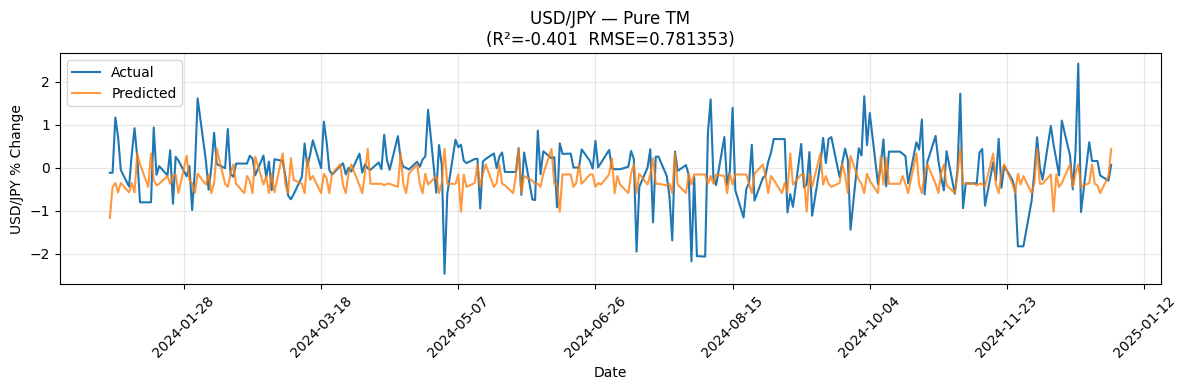

In [ ]:
results, rmse, mae, mape, r2, fi_standard, fi_shap, fi_perm, fi_lime = forecast_exchange_rate(
    df, use_macro=False, model='tsetlin', tune = True, feature_selection = False,
    use_scaling=True, hybrid = False
)
#

## XGB

Total: 8763 | Train: 8480 | Test: 241 | Features: 41
Train: 1990-02-01 → 2023-11-13
Test:  2023-12-14 → 2024-11-29

10 SAMPLE TEST PREDICTIONS
      date  actual_fx  predicted_fx     error  abs_error
2023-12-14   0.009343      0.000456 -0.008887   0.008887
2024-01-24  -0.001728     -0.000330  0.001398   0.001398
2024-03-04  -0.001121      0.000806  0.001927   0.001927
2024-04-10   0.001671     -0.000153 -0.001825   0.001825
2024-05-16   0.003301     -0.000037 -0.003338   0.003338
2024-06-26  -0.000715      0.000289  0.001004   0.001004
2024-08-05  -0.010409      0.000043  0.010452   0.010452
2024-09-11  -0.004299      0.000963  0.005262   0.005262
2024-10-21   0.006716      0.000309 -0.006407   0.006407
2024-11-29   0.000699      0.000785  0.000086   0.000086

                                        RMSE: 0.006568
                                         MAE:  0.004611
                                          R²: 0.0002
Inference time: 2778.819 ms


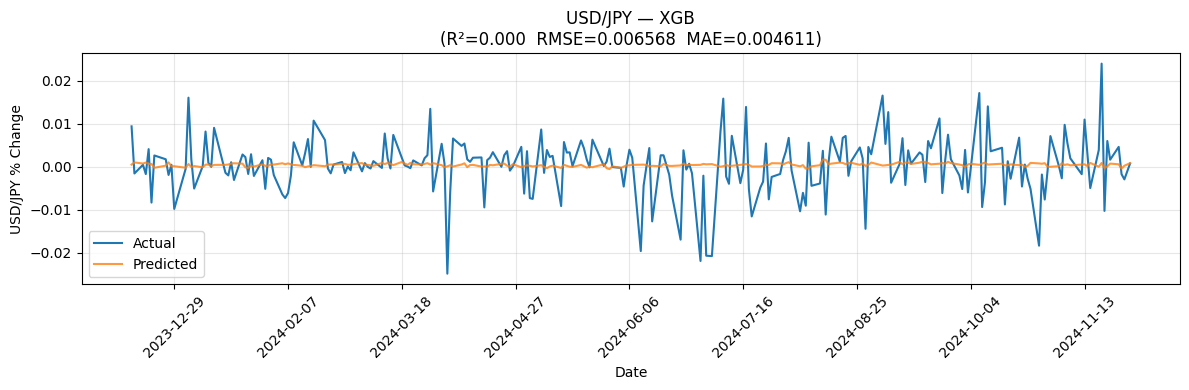

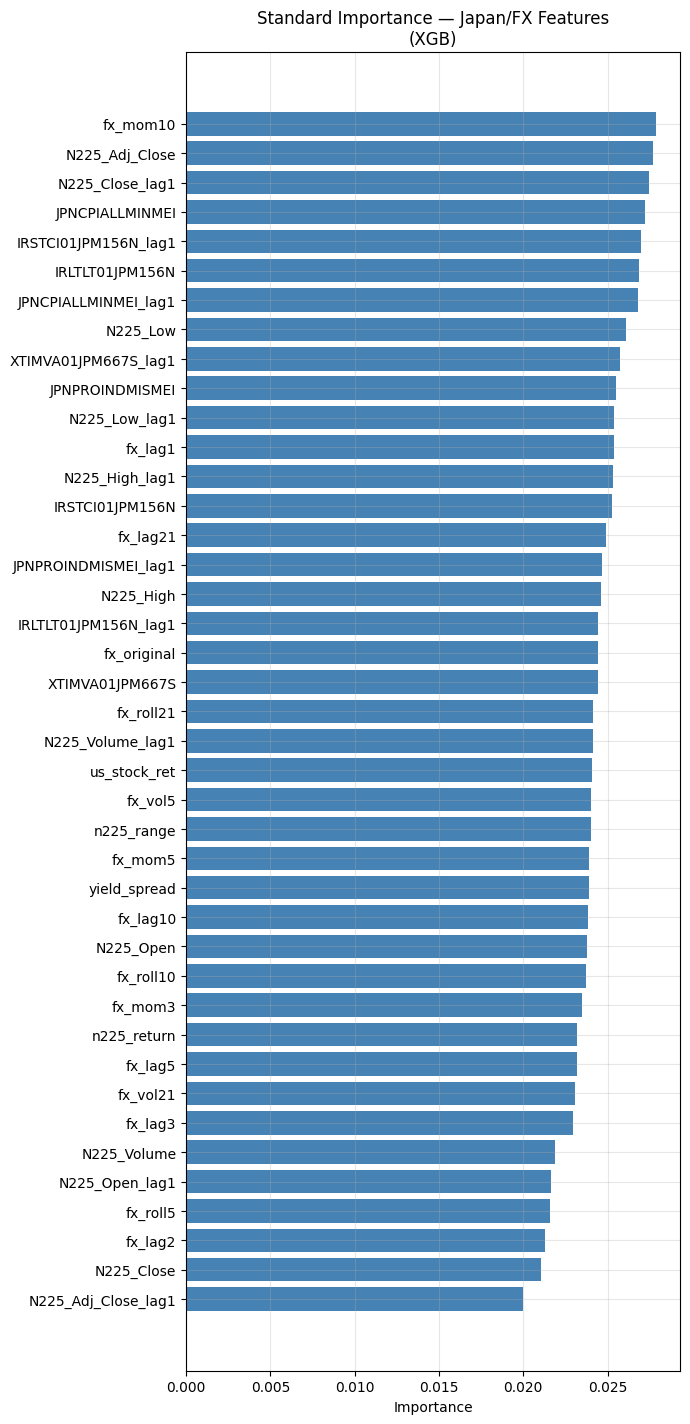

In [75]:
results, rmse, mae, mape, r2, fi_standard, fi_shap, fi_perm, fi_lime = forecast_exchange_rate(
    df, use_macro=False, model='XGB', tune = True, feature_selection = False,
    use_scaling=True, hybrid = False
)

Total: 9109 | Train: 8826 | Test: 241 | Features: 109
Train: 1990-02-01 → 2023-11-30
Test:  2024-01-01 → 2024-12-02

10 SAMPLE TEST PREDICTIONS
      date  actual_fx  predicted_fx     error  abs_error
2024-01-01    0.04064      0.066991  0.026351   0.026351
2024-02-06   -0.64606      0.080339  0.726399   0.726399
2024-03-14   -0.04569      0.136060  0.181750   0.181750
2024-04-22   -0.00641      0.107503  0.113913   0.113913
2024-05-28    0.62625      0.070276 -0.555974   0.555974
2024-07-04   -2.05251      0.128757  2.181267   2.181267
2024-08-12   -0.44780      0.133260  0.581060   0.581060
2024-09-17    0.32837      0.160825 -0.167545   0.167545
2024-10-24    0.04526      0.184570  0.139310   0.139310
2024-12-02    0.06995      0.160510  0.090560   0.090560

                                        RMSE: 0.690044
                                         MAE:  0.472554
                                          R²: -0.0706
Inference time: 2639.633 ms


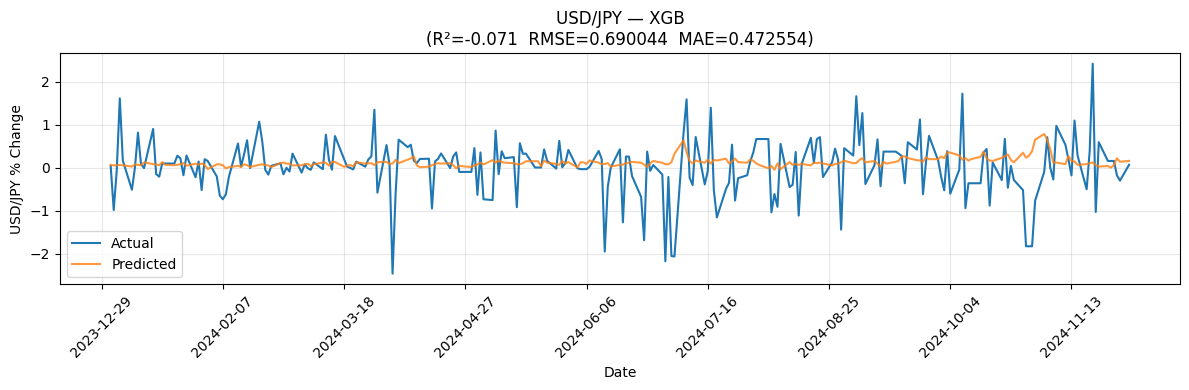

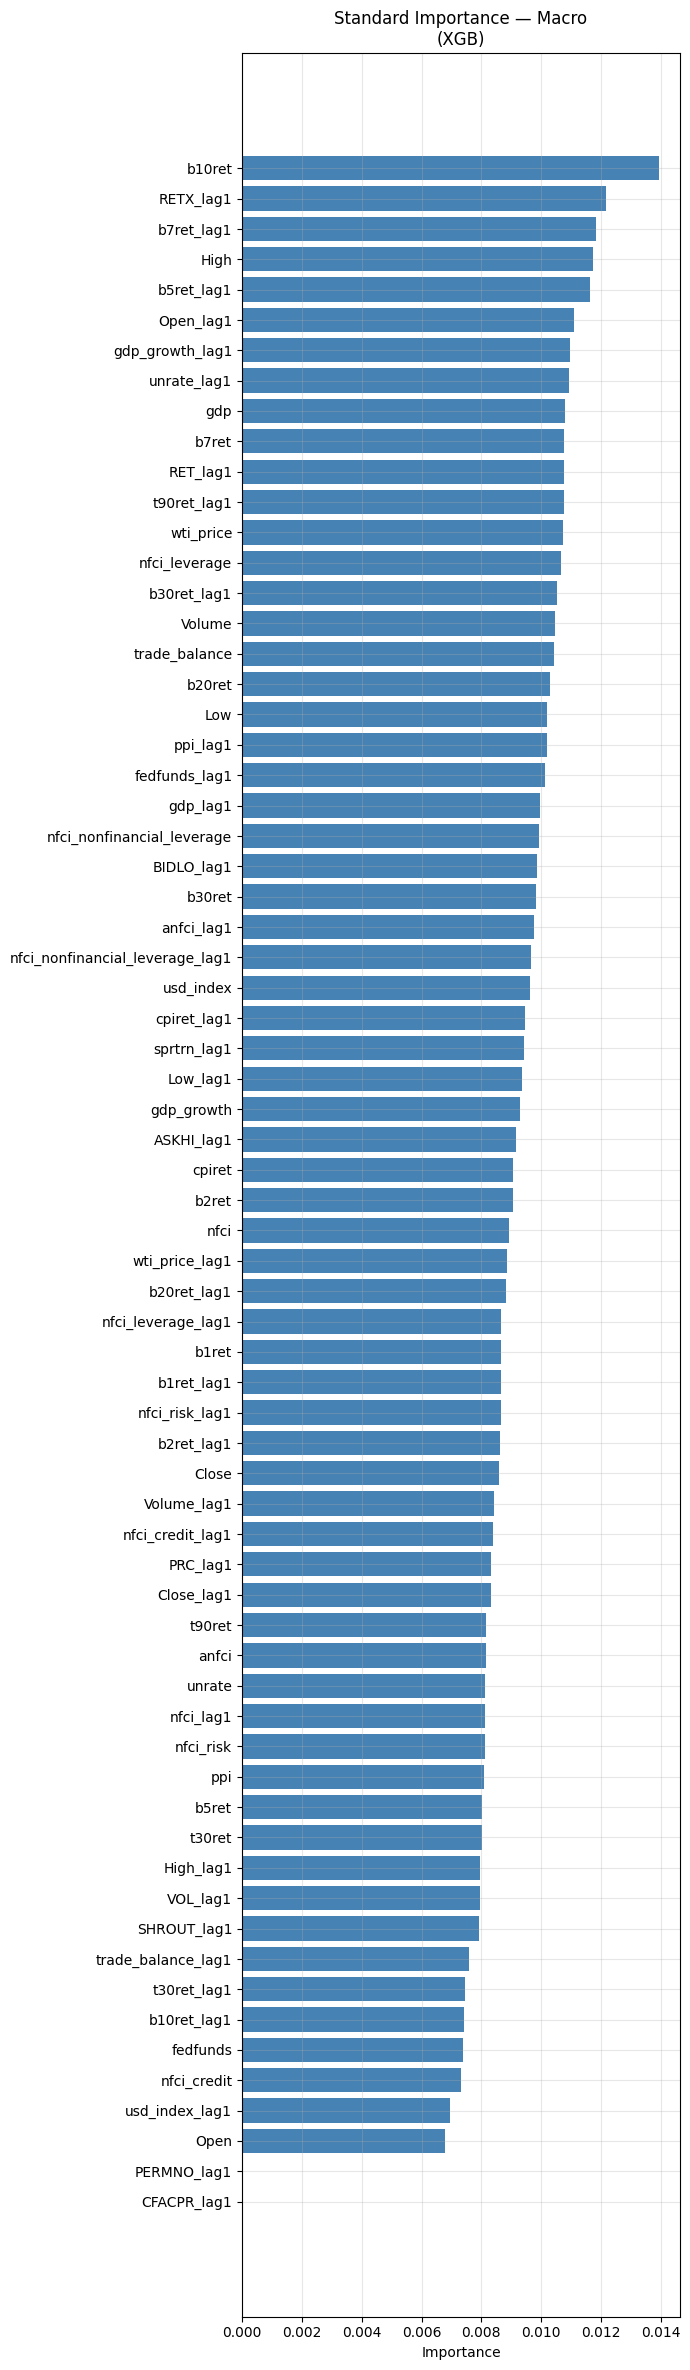

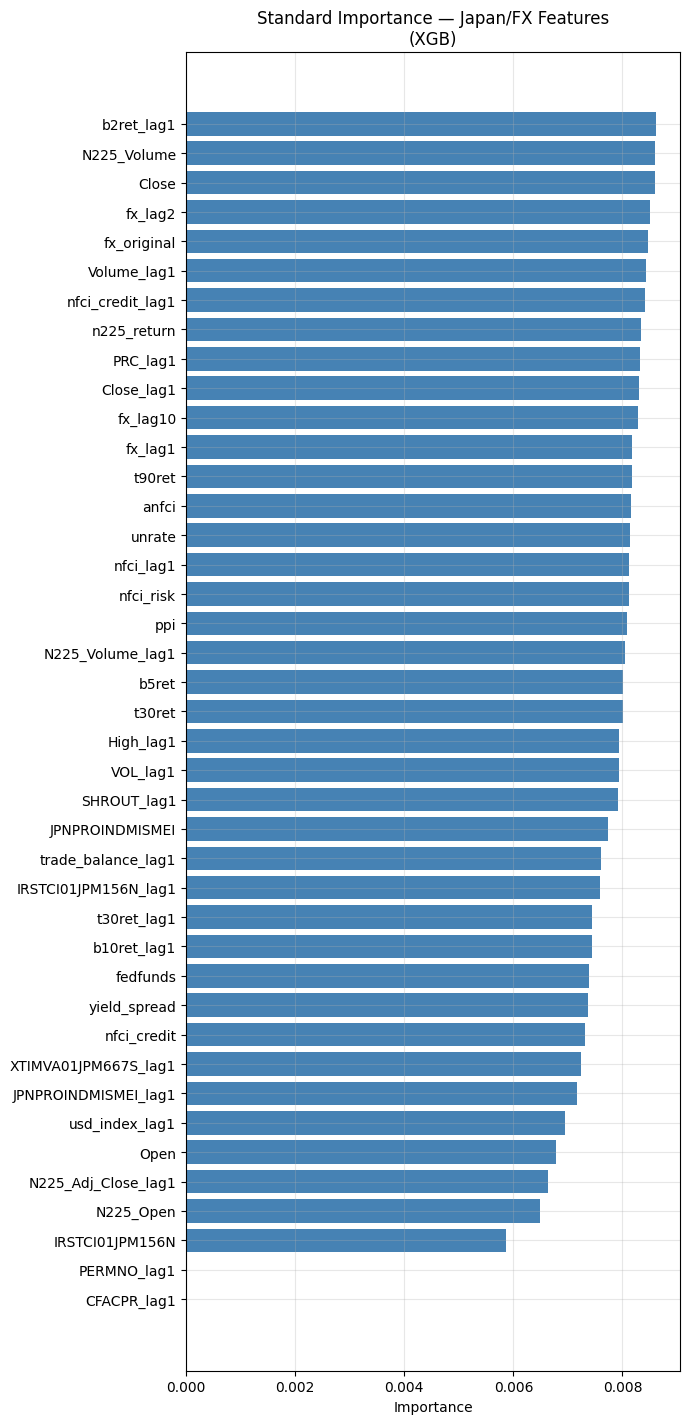

In [29]:
results, rmse, mae, mape, r2, fi_standard, fi_shap, fi_perm, fi_lime = forecast_exchange_rate(
    df, use_macro=True, model='XGB', tune = True, feature_selection = False,
    use_scaling=True, hybrid = False
)

## GB

Total: 9130 | Train: 8847 | Test: 262 | Features: 30
Train: 1990-02-01 → 2023-12-29
Test:  2024-01-01 → 2024-12-31

                                        RMSE: 0.661802
                                         MAE:  0.462031
                                          R²: -0.0052
Inference time: 730.578 ms


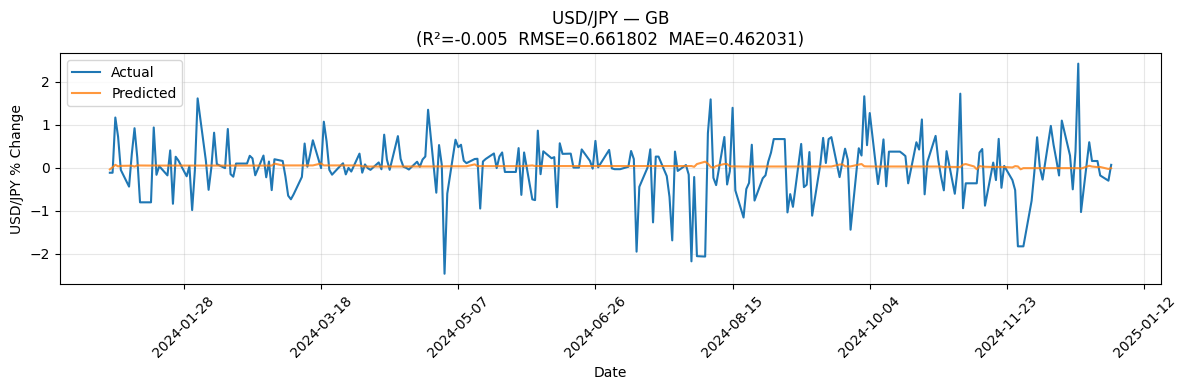

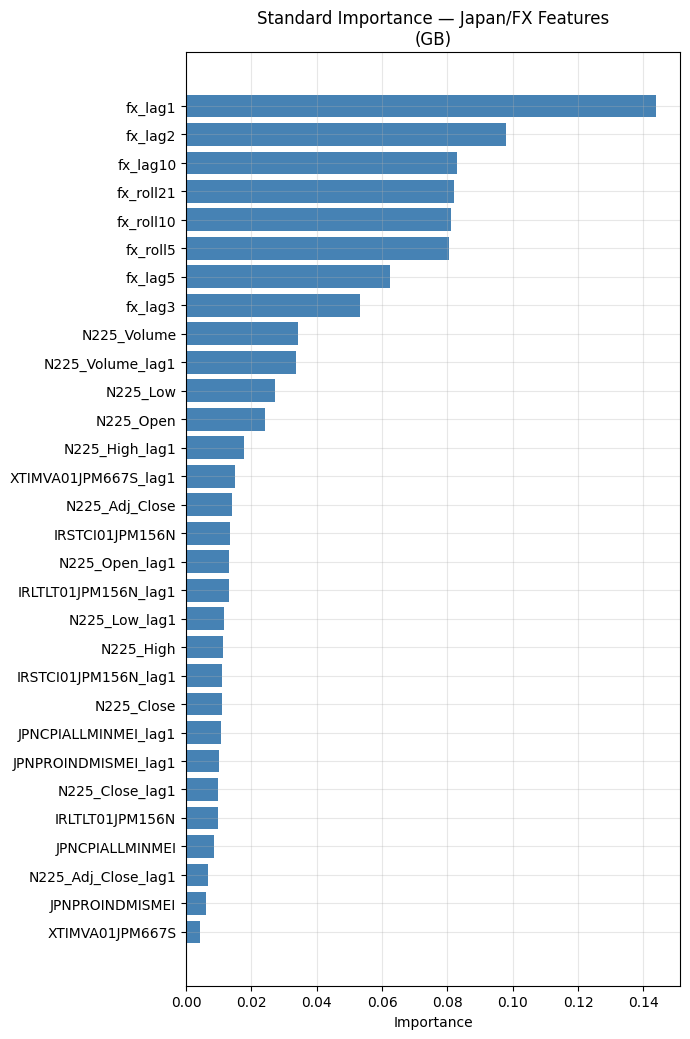

In [ ]:
results, rmse, mae, mape, r2, fi_standard, fi_shap, fi_perm, fi_lime = forecast_exchange_rate(
    df, use_macro=False, model='GB', tune = True, feature_selection = False,
    use_scaling=True, hybrid = False
)

Total: 9130 | Train: 8847 | Test: 262 | Features: 98
Train: 1990-02-01 → 2023-12-29
Test:  2024-01-01 → 2024-12-31

                                        RMSE: 0.662384
                                         MAE:  0.469428
                                          R²: -0.0070
Inference time: 1280.419 ms


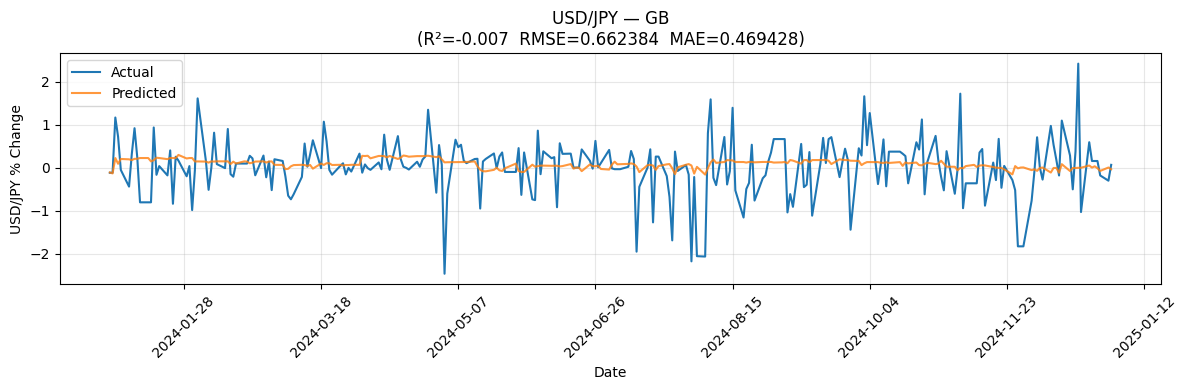

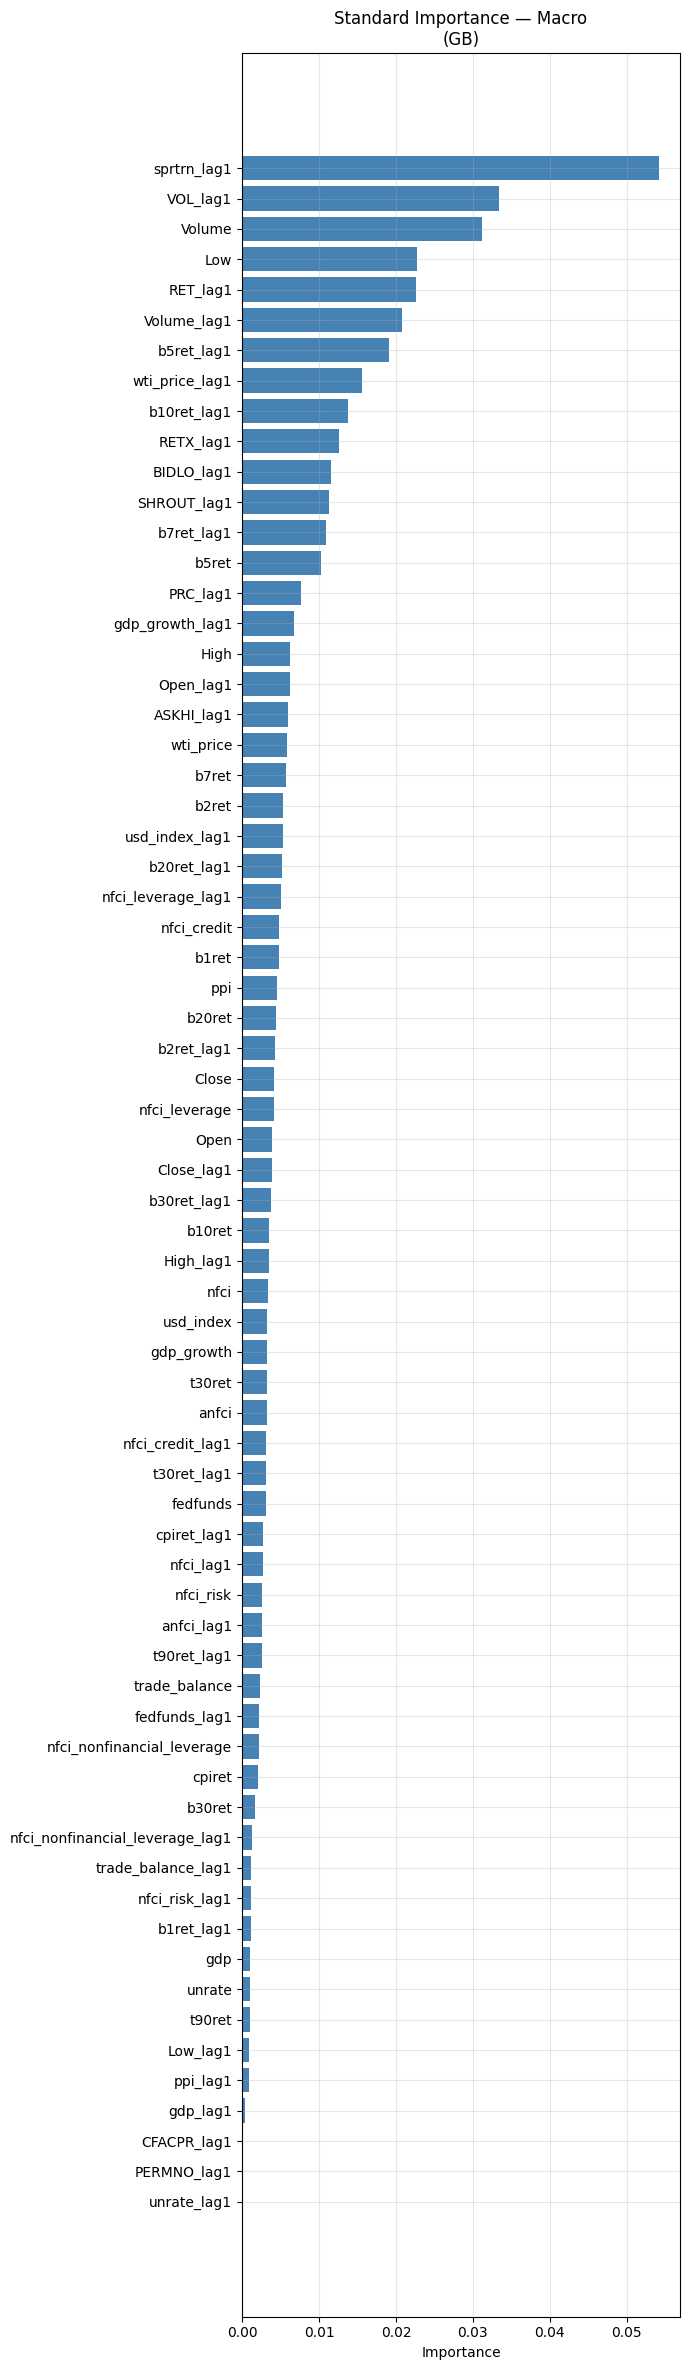

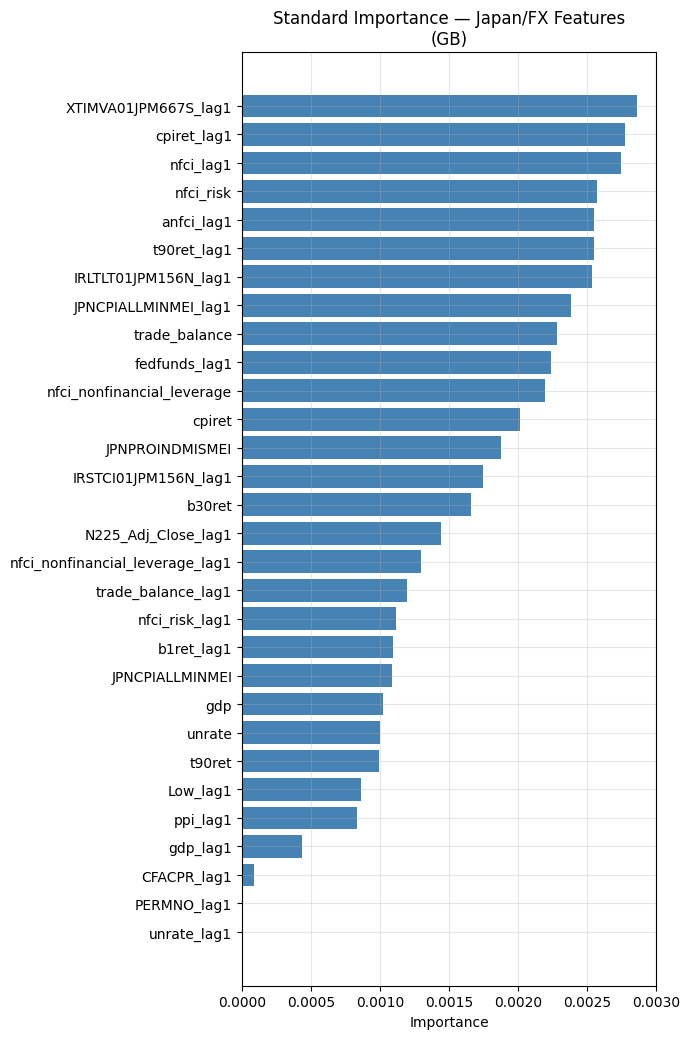

In [ ]:
results, rmse, mae, mape, r2, fi_standard, fi_shap, fi_perm, fi_lime = forecast_exchange_rate(
    df, use_macro=True, model='GB', tune = True, feature_selection = False,
    use_scaling=True, hybrid = False
)

## Catboost

Total: 9130 | Train: 8847 | Test: 262 | Features: 30
Train: 1990-02-01 → 2023-12-29
Test:  2024-01-01 → 2024-12-31

                                        RMSE: 0.666859
                                         MAE:  0.476644
                                          R²: -0.0206
Inference time: 927.956 ms


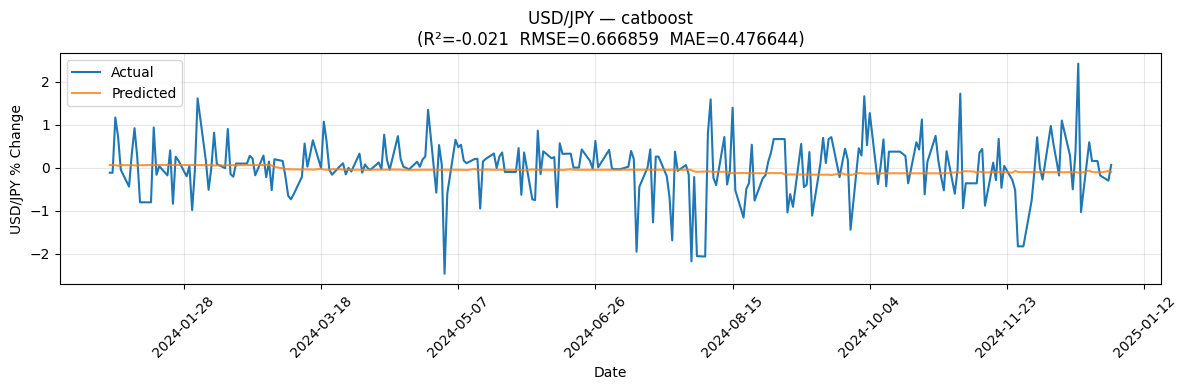

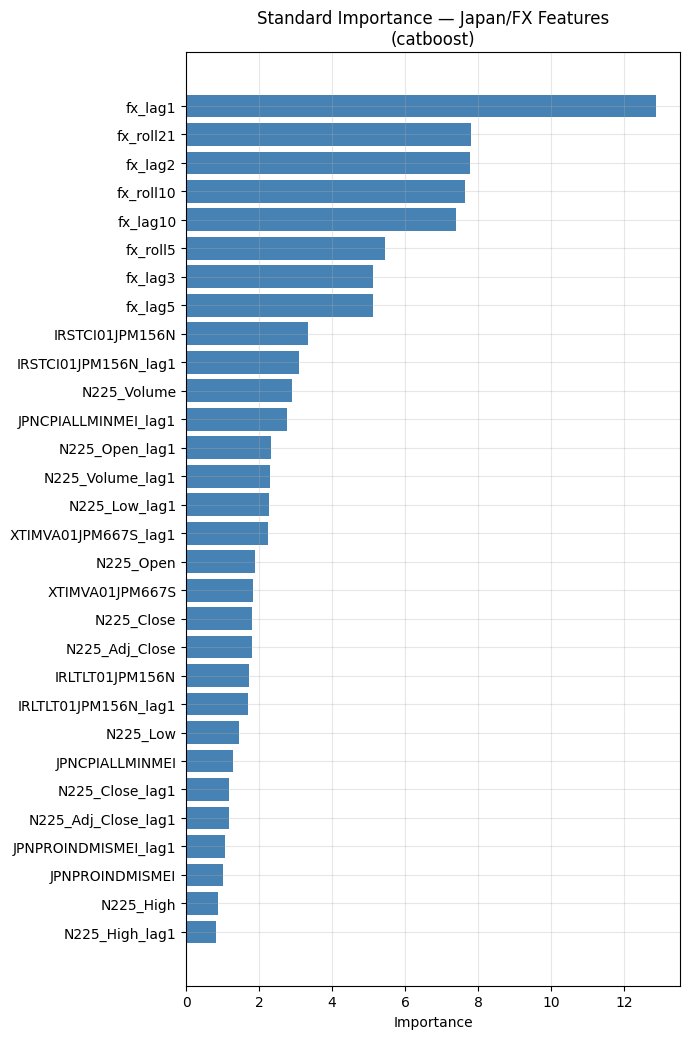

In [ ]:
results, rmse, mae, mape, r2, fi_standard, fi_shap, fi_perm, fi_lime = forecast_exchange_rate(
    df, use_macro=False, model='catboost', tune = True, feature_selection = False,
    use_scaling=True, hybrid = False
)

Total: 9130 | Train: 8847 | Test: 262 | Features: 98
Train: 1990-02-01 → 2023-12-29
Test:  2024-01-01 → 2024-12-31

                                        RMSE: 0.646059
                                         MAE:  0.461585
                                          R²: 0.0420
Inference time: 1366.102 ms


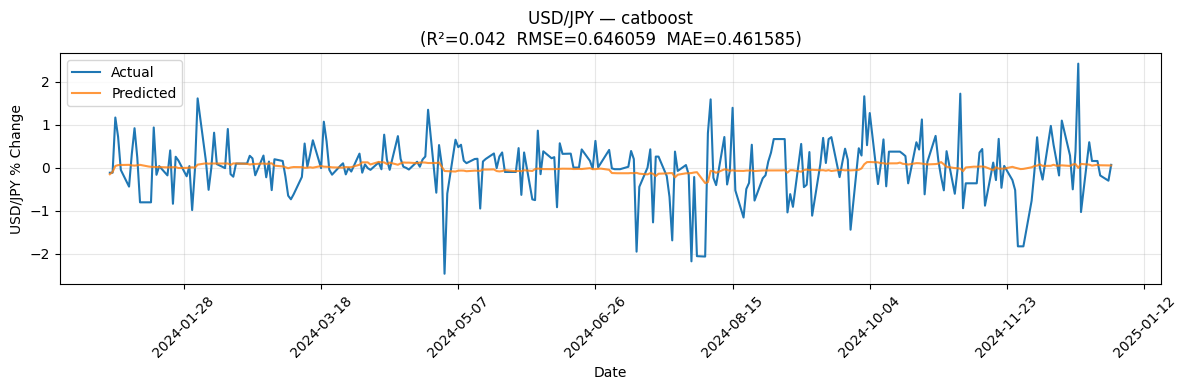

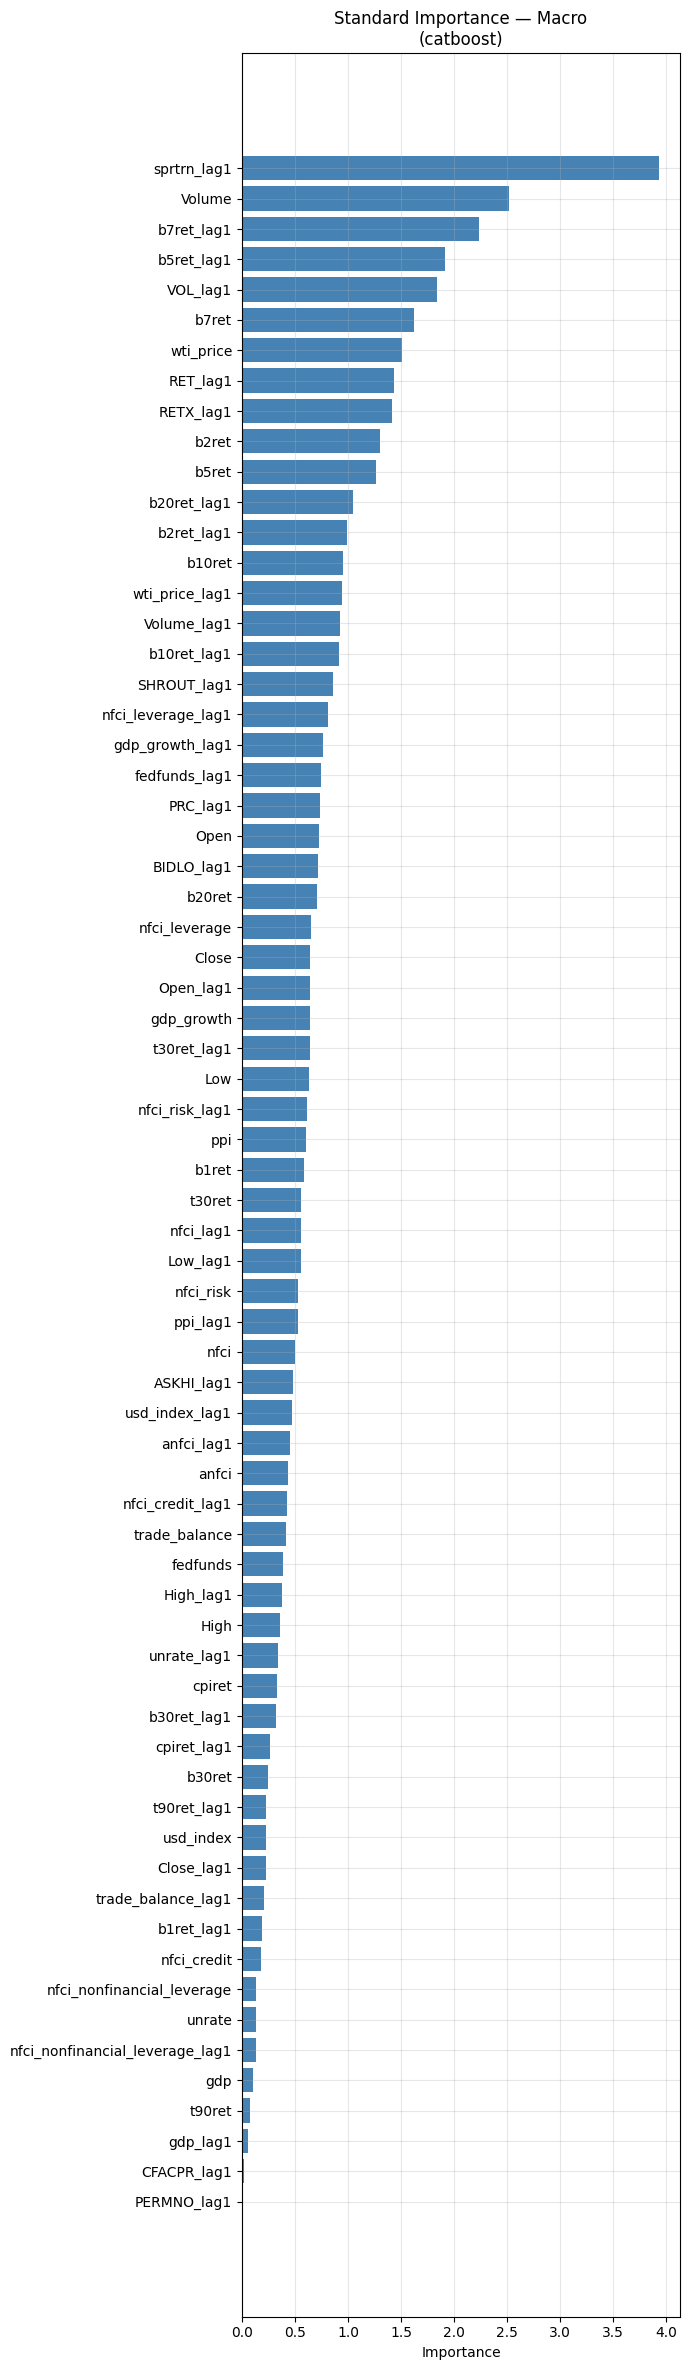

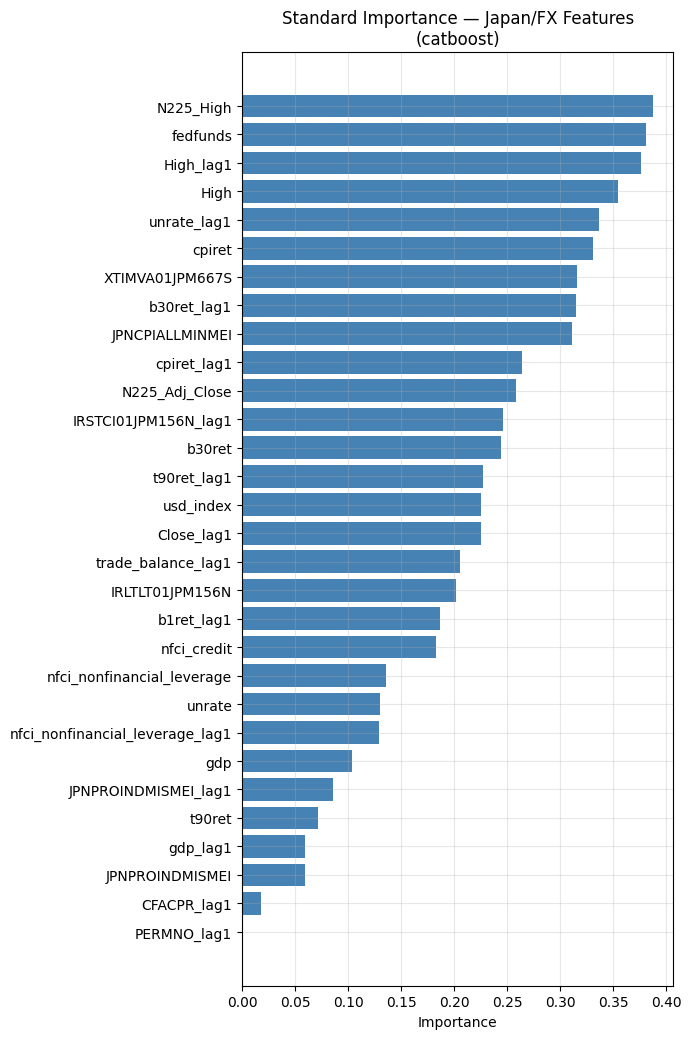

In [ ]:
results, rmse, mae, mape, r2, fi_standard, fi_shap, fi_perm, fi_lime = forecast_exchange_rate(
    df, use_macro=True, model='catboost', tune = True, feature_selection = False,
    use_scaling=True, hybrid = False
)

## SVR

Total: 9130 | Train: 8847 | Test: 262 | Features: 30
Train: 1990-02-01 → 2023-12-29
Test:  2024-01-01 → 2024-12-31

                                        RMSE: 0.711766
                                         MAE:  0.528526
                                          R²: -0.1627
Inference time: 2168.584 ms


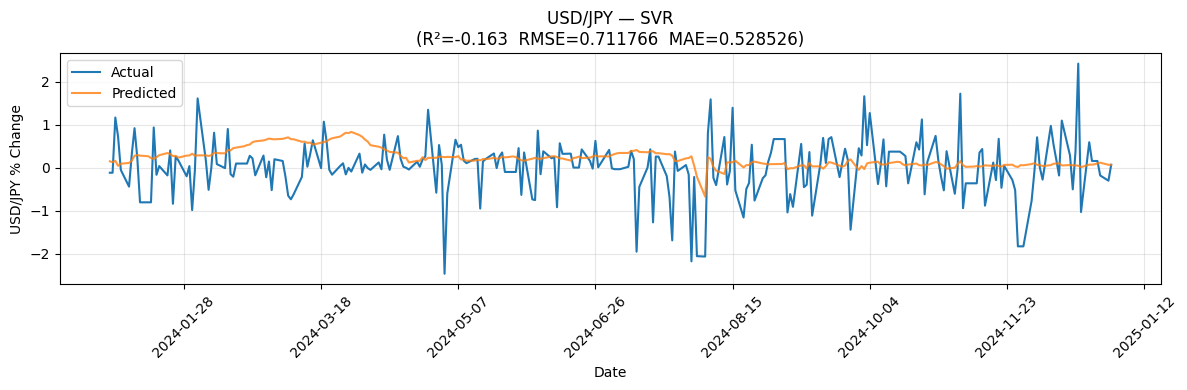

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/valida

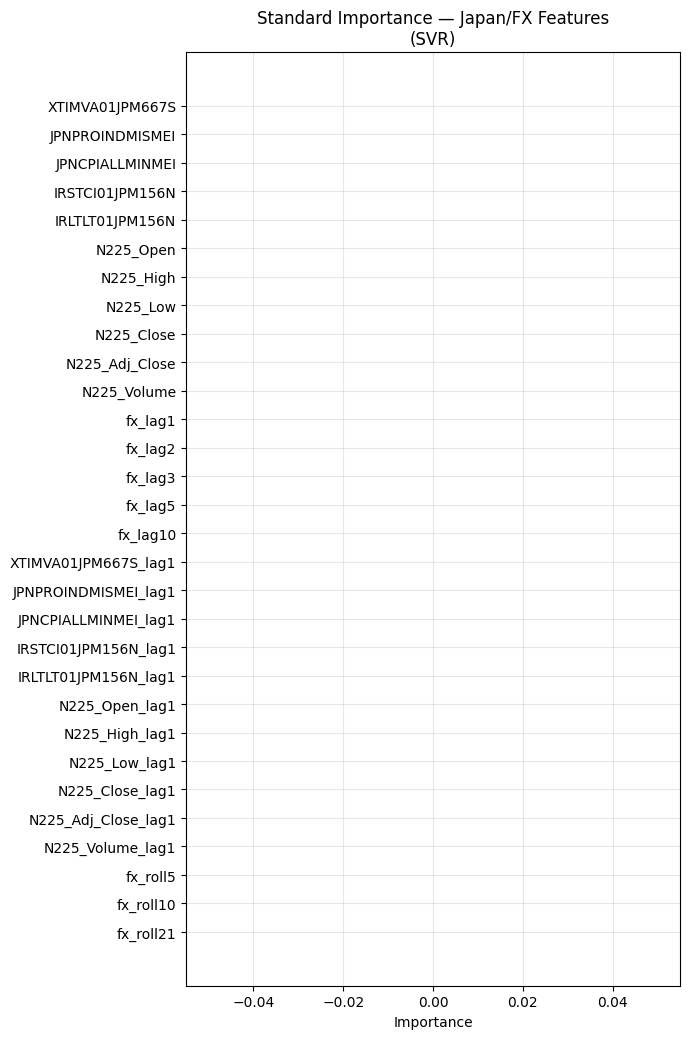

In [ ]:
results, rmse, mae, mape, r2, fi_standard, fi_shap, fi_perm, fi_lime = forecast_exchange_rate(
    df, use_macro=False, model='SVR', tune = True, feature_selection = False,
    use_scaling=True, hybrid = False
)

Total: 9130 | Train: 8847 | Test: 262 | Features: 98
Train: 1990-02-01 → 2023-12-29
Test:  2024-01-01 → 2024-12-31

                                        RMSE: 0.683261
                                         MAE:  0.511632
                                          R²: -0.0715
Inference time: 1083.709 ms


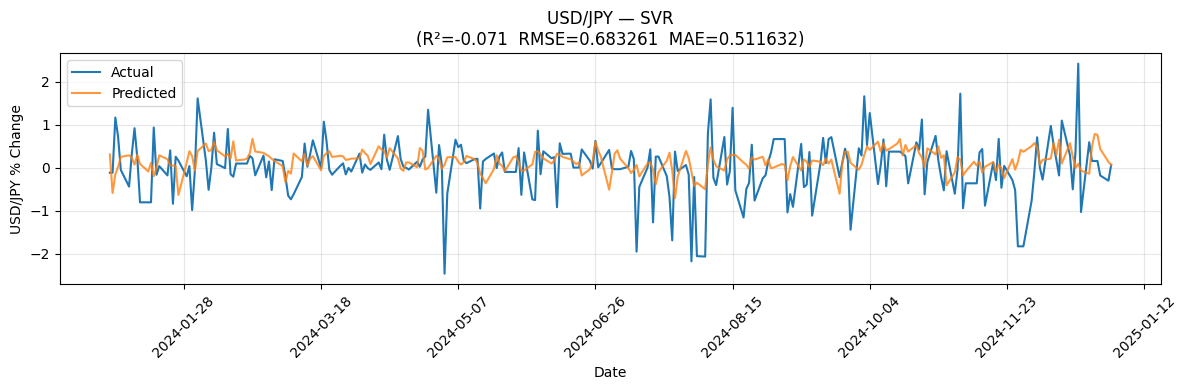

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
results, rmse, mae, mape, r2, fi_standard, fi_shap, fi_perm, fi_lime = forecast_exchange_rate(
    df, use_macro=True, model='SVR', tune = True, feature_selection = False,
    use_scaling=True, hybrid = False
)

## KNN

In [ ]:
results, rmse, mae, mape, r2, fi_standard, fi_shap, fi_perm, fi_lime = forecast_exchange_rate(
    df, use_macro=False, model='KNN', tune = True, feature_selection = False,
    use_scaling=True, hybrid = False
)

In [ ]:
results, rmse, mae, mape, r2, fi_standard, fi_shap, fi_perm, fi_lime = forecast_exchange_rate(
    df, use_macro=True, model='KNN', tune = True, feature_selection = False,
    use_scaling=True, hybrid = False
)

## bayes

Total: 9130 | Train: 8847 | Test: 262 | Features: 30
Train: 1990-02-01 → 2023-12-29
Test:  2024-01-01 → 2024-12-31

                                        RMSE: 0.660904
                                         MAE:  0.462332
                                          R²: -0.0025
Inference time: 892.348 ms


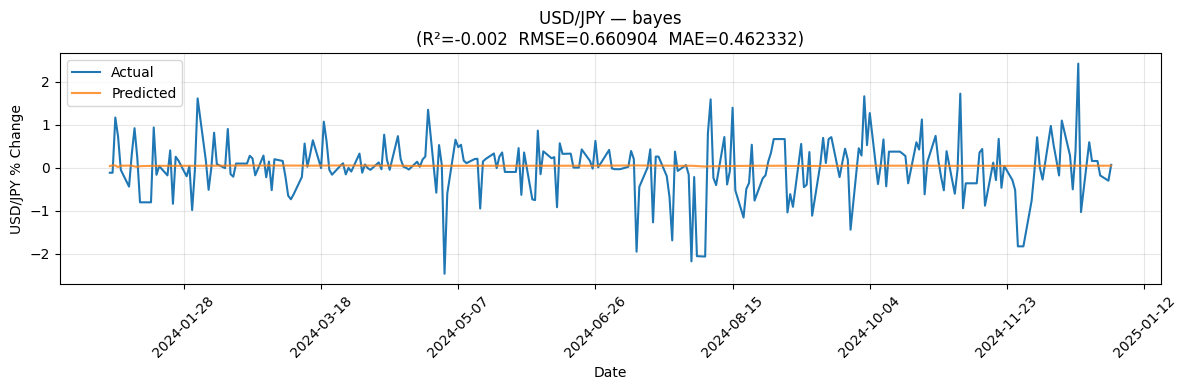

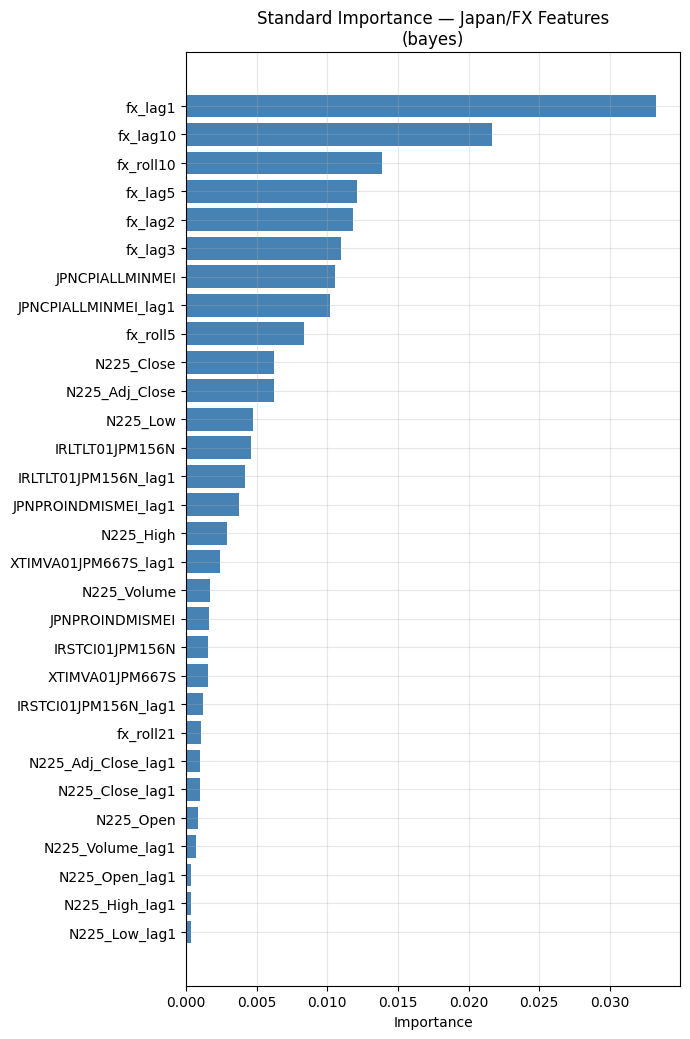

In [ ]:
results, rmse, mae, mape, r2, fi_standard, fi_shap, fi_perm, fi_lime = forecast_exchange_rate(
    df, use_macro=False, model='bayes', tune = True, feature_selection = False,
    use_scaling=True, hybrid = False
)

Total: 9130 | Train: 8847 | Test: 262 | Features: 98
Train: 1990-02-01 → 2023-12-29
Test:  2024-01-01 → 2024-12-31

                                        RMSE: 0.648437
                                         MAE:  0.457213
                                          R²: 0.0350
Inference time: 884.036 ms


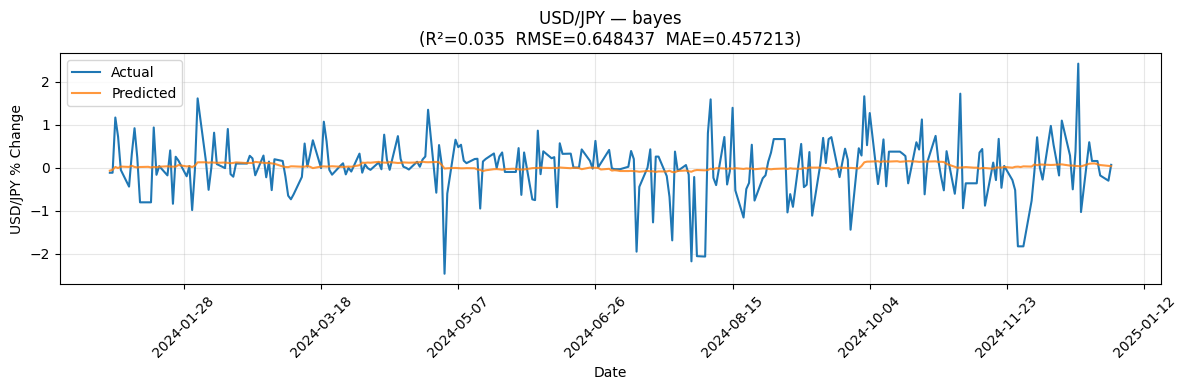

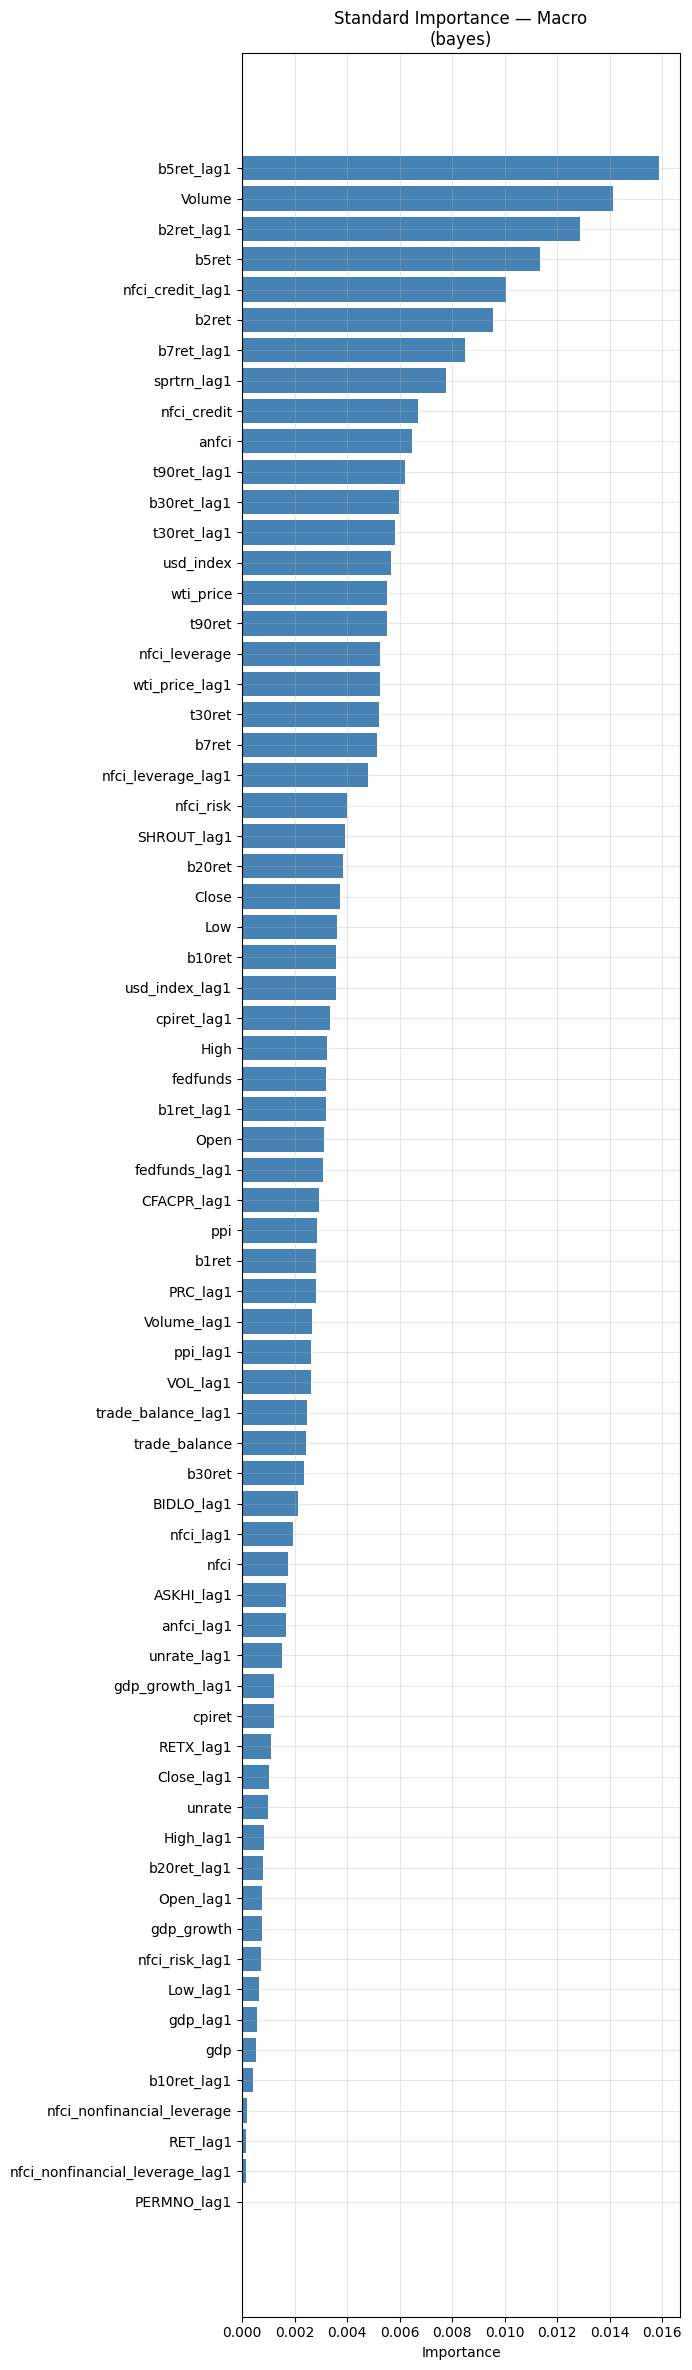

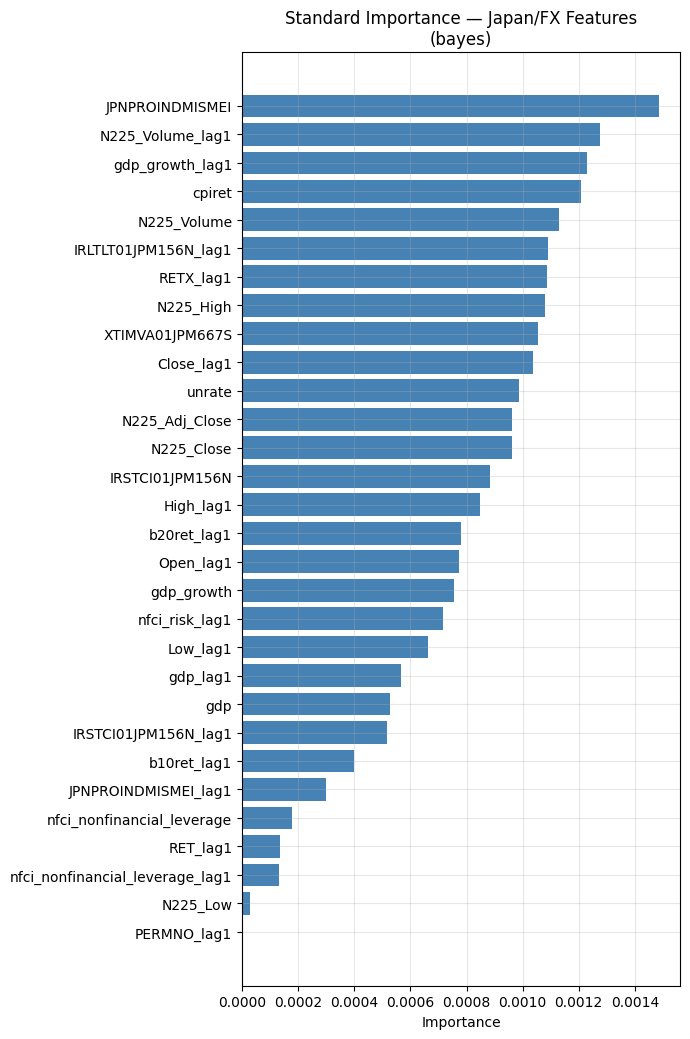

In [ ]:
results, rmse, mae, mape, r2, fi_standard, fi_shap, fi_perm, fi_lime = forecast_exchange_rate(
    df, use_macro=True, model='bayes', tune = True, feature_selection = False,
    use_scaling=True, hybrid = False
)

## ARIMA

Total: 9130 | Train: 8847 | Test: 262 | Features: 30
Train: 1990-02-01 → 2023-12-29
Test:  2024-01-01 → 2024-12-31

ARIMA — Best AIC: 17481.34
Date                  Actual    Predicted      Error
-----------------------------------------------------------------
2024-01-01          -0.11341     -0.03292    0.08049
2024-01-30           0.04064     -0.00000    0.04064
2024-02-28           0.14622      0.00000    0.14622
2024-03-28           0.00000      0.00000    0.00000
2024-04-26           1.35031      0.00000    1.35031
2024-05-27          -0.09551      0.00000    0.09551
2024-06-25          -0.01878      0.00000    0.01878
2024-07-24          -1.68568     -0.00000    1.68568
2024-08-22           0.53723     -0.00000    0.53723
2024-09-20           0.71389     -0.00000    0.71389
2024-10-21           0.59500     -0.00000    0.59500
2024-11-19          -0.28427     -0.00000    0.28427
2024-12-18           0.38459      0.00000    0.38459
  (showing every ~21 days)
----------------------

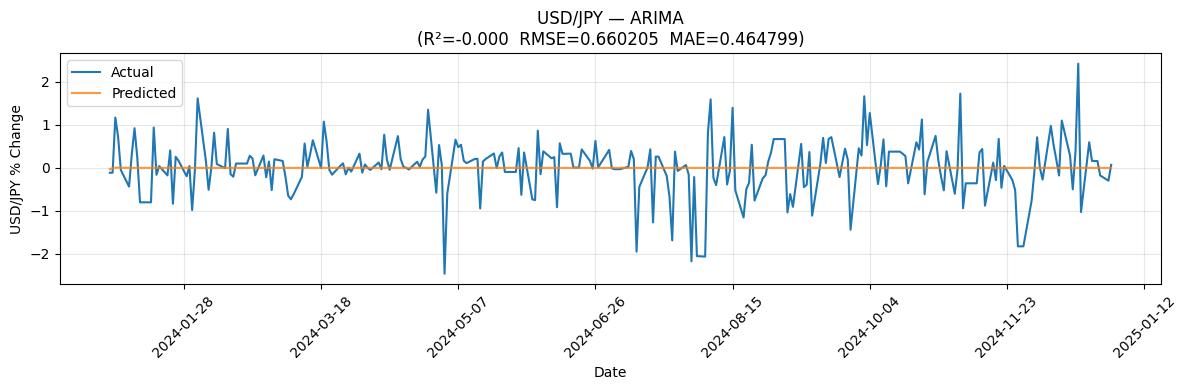

ValueError: not enough values to unpack (expected 9, got 5)

In [ ]:
results, rmse, mae, mape, r2, fi_standard, fi_shap, fi_perm, fi_lime = forecast_exchange_rate(
    df, use_macro=False, model='arima', tune = True, feature_selection = False,
    use_scaling=True, hybrid = False
)

In [ ]:
results, rmse, mae, mape, r2, fi_standard, fi_shap, fi_perm, fi_lime = forecast_exchange_rate(
    df, use_macro=True, model='arima', tune = True, feature_selection = False,
    use_scaling=True, hybrid = False
)